# Notebook experimental completo — QAOA-MPS para TSP

## Statevector exacto vs. Tensor Network

Esta notebook está preparada como **plataforma experimental final del TFM**. El objetivo es poder responder de forma cuantitativa a las cuatro hipótesis principales:

- **H1 — Eficiencia:** la representación MPS puede reducir el coste de simulación de QAOA.
- **H2 — Entrelazamiento:** la eficiencia MPS está condicionada por el crecimiento del entrelazamiento.
- **H3 — Truncación:** existe un compromiso entre precisión, bond dimension y coste computacional.
- **H4 — Profundidad:** aumentar la profundidad de QAOA puede incrementar la complejidad tensorial.

La cadena experimental es:

$$
\boxed{
\text{Solomon C101}
\rightarrow
\text{TSP}
\rightarrow
\text{QUBO}
\rightarrow
\text{Ising}
\rightarrow
\text{QAOA}
\rightarrow
\text{MPS}
}
$$

frente a

$$
\boxed{
\text{QAOA}
\rightarrow
\text{statevector exacto}.
}
$$

> **Regla de seguridad:** nunca se construye `ising_op.to_matrix()` en los experimentos. La energía se calcula directamente con el operador `SparsePauliOp`, evitando matrices densas de dimensión $2^{n_q}\times2^{n_q}$.

---

## Experimentos incluidos

| Experimento | Variables principales | Hipótesis |
|---|---|---|
| Validación exacta | $F,\Delta E,\chi,t$ | Validación |
| A. Truncación | $\chi,F,\Delta E,t$ | H3 |
| B. Profundidad | $p,\chi,t$ | H4 |
| C. Escalabilidad | $N,n_q,\chi,t,M_{SV}$ | H1/H2 |
| D. Entrelazamiento | $S_b,\chi_b$ | H2 |
| E. Régimen de fallo | $\chi,F,\Delta E$ | H2/H3 |
| F. Parámetros QAOA | $\gamma,\beta,F,\Delta E,\chi,t$ | H2/H3 |
| G. Escalabilidad exacta | $t_{SV}$ vs. $t_{MPS}$ | H1 |

Los experimentos exactos se limitan automáticamente a tamaños seguros para evitar que el statevector provoque la muerte del kernel.


# 1. Configuración

Este notebook centraliza todos los parámetros experimentales y mantiene una separación
explícita entre validación, experimentos y análisis. Los experimentos costosos están
desactivados por defecto para que ``Run All`` no provoque una ejecución accidental
de simulaciones grandes.

Los resultados se guardan como CSV y las figuras como PNG. La validación exacta
pequeña permanece activada porque constituye una comprobación fundamental de la
implementación MPS frente al statevector.

La nueva métrica de **coste de representación** compara:

$$
N_{\mathrm{SV}}=2^n
$$

con el número de coeficientes escalares almacenados por la MPS:

$$
N_{\mathrm{MPS}}
=
\sum_{i=1}^{n}2\chi_{i-1}\chi_i,
\qquad
\chi_0=\chi_n=1.
$$



In [10]:
from pathlib import Path
import sys
import time
import os
import gc
import platform
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Rutas
# ---------------------------------------------------------------------
ROOT = Path("/app")
if not ROOT.exists():
    ROOT = Path.cwd()

sys.path.insert(0, str(ROOT))

RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures_final"
RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Interruptores experimentales
#
# La validación queda activa por defecto.
# ---------------------------------------------------------------------
RUN_VALIDATION = True
RUN_TRUNCATION = True
RUN_DEPTH = True
RUN_SCALING = True
RUN_ENTANGLEMENT = True
RUN_FAILURE_REGIME = True
RUN_PARAMETER_SWEEP = True
RUN_EXACT_SCALING = True
RUN_REPRESENTATION_REPORT = True
RUN_MASTER_TABLE = True

# ---------------------------------------------------------------------
# Configuración científica
# ---------------------------------------------------------------------
GAMMA = 0.35
BETA = 0.20

VALIDATION_N = 3
VALIDATION_DEPTH = 2

TRUNCATION_N = 4
TRUNCATION_DEPTH = 1
TRUNCATION_CHIS = (2, 4, 8, 16, 32, 64, 128)

DEPTH_N = 3
DEPTHS = (1, 2, 3, 4, 5)
DEPTH_MAX_BOND = 128

# Escalabilidad MPS y coste de representación.
SCALING_SIZES = (2, 3, 4, 5, 6)
SCALING_DEPTH = 1
SCALING_MAX_BOND = 128

ENTANGLEMENT_N = 3
ENTANGLEMENT_DEPTHS = (1, 2, 3, 4)

FAILURE_N = 4
FAILURE_DEPTH = 2
FAILURE_CHIS = (2, 4, 8, 16, 32, 64, 128)

PARAMETER_N = 3
PARAMETER_DEPTH = 2
GAMMAS = (0.15, 0.25, 0.35, 0.45, 0.55)
BETAS = (0.10, 0.20, 0.30, 0.40)

# Referencia exacta: límite conservador.
# complex128 -> 16 bytes por amplitud.
EXACT_MAX_QUBITS = 16
STATEVECTOR_BYTES_PER_AMPLITUDE = np.dtype(np.complex128).itemsize

# Umbrales para interpretación automática.
FIDELITY_THRESHOLD = 0.99
ENERGY_TOLERANCE = 1e-3

print("ROOT:", ROOT)
print("RESULTS:", RESULTS)
print("Python:", platform.python_version())
print("complex128 bytes/amplitude:", STATEVECTOR_BYTES_PER_AMPLITUDE)


ROOT: /app
RESULTS: /app/results
Python: 3.11.16
complex128 bytes/amplitude: 16


In [11]:
import qiskit
import qiskit_optimization
import quimb
import quimb.tensor as qtn

print("Qiskit:", qiskit.__version__)
print("Qiskit Optimization:", qiskit_optimization.__version__)
print("Quimb:", quimb.__version__)


Qiskit: 2.1.1
Qiskit Optimization: 0.7.0
Quimb: 1.11.2


# 2. Datos reales y construcción del problema TSP

Se utiliza Solomon C101 y el mismo pipeline desarrollado para el TFM.

El encoding posición-tiempo utiliza:

$$
x_{i,t}\in\{0,1\}
$$

y las restricciones de unicidad se incorporan mediante penalizaciones QUBO. Después se transforma el QUBO en un Hamiltoniano Ising.

**Importante:** se conserva exactamente la convención del notebook original: `n_customers` selecciona las primeras filas del dataset mediante `df.iloc[:n_customers]`.


In [12]:
from app.datasets.solomon_loader import load_solomon
from app.graph.graph_builder import build_graph
from app.graph.distance_matrix import build_distance_matrix
from app.optimization.qubo import build_tsp_qubo
from qiskit_optimization.converters import QuadraticProgramToQubo

DATASET = ROOT / "datasets" / "solomon" / "C101.txt"
df = load_solomon(str(DATASET))


def make_tsp_instance(n_customers):
    sub = df.iloc[:n_customers].copy()
    G = build_graph(sub)
    D = build_distance_matrix(G)
    qp = build_tsp_qubo(D)
    qubo = QuadraticProgramToQubo().convert(qp)
    ising_op, offset = qubo.to_ising()
    return sub, D, qp, qubo, ising_op, offset


def statevector_amplitudes(n_qubits):
    """Número de amplitudes complejas de un statevector denso."""
    return int(2 ** n_qubits)


def statevector_memory_bytes(n_qubits):
    """Memoria mínima teórica de un statevector complex128."""
    return int(
        STATEVECTOR_BYTES_PER_AMPLITUDE
        * statevector_amplitudes(n_qubits)
    )


def memory_statevector_gb(n_qubits):
    """Memoria mínima teórica del statevector complex128 en GiB."""
    return statevector_memory_bytes(n_qubits) / (1024 ** 3)


def mps_tensor_elements_from_bonds(bonds):
    """
    Número de coeficientes escalares de una MPS de qubits.

    Si los enlaces son chi_1,...,chi_{n-1}, entonces:

        N_MPS = sum_i 2 * chi_{i-1} * chi_i,

    con chi_0 = chi_n = 1.
    """
    bonds = np.asarray(bonds, dtype=int).reshape(-1)
    chi = np.concatenate(([1], bonds, [1]))

    n = len(bonds) + 1

    return int(
        sum(
            2 * chi[i] * chi[i + 1]
            for i in range(n)
        )
    )


def mps_estimated_memory_bytes_from_bonds(bonds):
    """Memoria teórica de los coeficientes MPS suponiendo complex128."""
    return int(
        STATEVECTOR_BYTES_PER_AMPLITUDE
        * mps_tensor_elements_from_bonds(bonds)
    )


def mps_estimated_memory_gb_from_bonds(bonds):
    """Memoria teórica de los coeficientes MPS en GiB."""
    return (
        mps_estimated_memory_bytes_from_bonds(bonds)
        / (1024 ** 3)
    )


def representation_compression_ratio(n_qubits, mps_elements):
    """
    Ratio entre el número de amplitudes del statevector
    y el número de coeficientes tensoriales de la MPS.

        R = N_SV / N_MPS

    R > 1 implica una representación MPS más compacta en
    número de coeficientes almacenados.
    """
    if mps_elements <= 0:
        return np.nan

    return statevector_amplitudes(n_qubits) / mps_elements


sub, D, qp, qubo, ising, offset = make_tsp_instance(VALIDATION_N)

print("Filas utilizadas:", len(sub))
print("Qubits:", ising.num_qubits)
print("Amplitudes statevector:", statevector_amplitudes(ising.num_qubits))
print(
    "Memoria statevector teórica:",
    f"{memory_statevector_gb(ising.num_qubits):.6f} GiB"
)


Filas utilizadas: 3
Qubits: 9
Amplitudes statevector: 512
Memoria statevector teórica: 0.000008 GiB


In [13]:
# Inspección numérica opcional de la instancia.
print("=== MATRIZ DE DISTANCIAS ===")
display(pd.DataFrame(D))

print("\n=== VARIABLES QUBO ===")
print("Número de variables:", qubo.get_num_vars())

print("\n=== ISING ===")
print(ising)
print("\nOffset:", offset)


=== MATRIZ DE DISTANCIAS ===


,0,1,2
0,0.000000,18.681542,20.615528
1,18.681542,0.000000,2.000000
2,20.615528,2.000000,0.000000



=== VARIABLES QUBO ===
Número de variables: 9

=== ISING ===
SparsePauliOp(['IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIZIIZ', 'IIIIZIIIZ', 'IIIZIIIIZ', 'IIZIIIIIZ', 'IZIIIIIIZ', 'ZIIIIIIIZ', 'IIIIIIZZI', 'IIIIIZIZI', 'IIIIZIIZI', 'IIIZIIIZI', 'IIZIIIIZI', 'IZIIIIIZI', 'ZIIIIIIZI', 'IIIIIZZII', 'IIIIZIZII', 'IIIZIIZII', 'IIZIIIZII', 'IZIIIIZII', 'ZIIIIIZII', 'IIIIZZIII', 'IIIZIZIII', 'IIZIIZIII', 'IZIIIZIII', 'ZIIIIZIII', 'IIIZZIIII', 'IIZIZIIII', 'IZIIZIIII', 'ZIIIZIIII', 'IIZZIIIII', 'IZIZIIIII', 'ZIIZIIIII', 'IZZIIIIII', 'ZIZIIIIII', 'ZZIIIIIII'],
              coeffs=[-268.43095383+0.j, -268.43095383+0.j, -268.43095383+0.j,
 -259.12318977+0.j, -259.12318977+0.j, -259.12318977+0.j,
 -260.09018299+0.j, -260.09018299+0.j, -260.09018299+0.j,
  124.39120946+0.j,  124.39120946+0.j,  124.39120946+0.j,
    4.67038542+0.j,    4.67038542+0.j,  124.39120946+0.j,
    5.15388203+0.j,    5.1

# 3. Hamiltoniano Ising y puertas QAOA

Se trabaja con:

$$
H_C=c_0I+\sum_i h_iZ_i+\sum_{i<j}J_{ij}Z_iZ_j.
$$

Las evoluciones se implementan mediante:

$$
e^{-i\gamma h_iZ_i}=R_Z(2\gamma h_i)
$$

y

$$
e^{-i\gamma J_{ij}Z_iZ_j}=R_{ZZ}(2\gamma J_{ij}).
$$

El mixer es:

$$
H_M=\sum_i X_i,
\qquad
e^{-i\beta X_i}=R_X(2\beta).
$$


In [14]:
def extract_ising_terms(ising_op):
    """Extrae únicamente términos Z y ZZ del SparsePauliOp."""
    z_terms = []
    zz_terms = []

    for label, coeff in zip(
        ising_op.paulis.to_labels(),
        ising_op.coeffs
    ):
        coeff = float(np.real_if_close(coeff))
        active = []

        for q in range(ising_op.num_qubits):
            pauli = label[ising_op.num_qubits - 1 - q]
            if pauli != "I":
                active.append((q, pauli))

        if len(active) == 1 and active[0][1] == "Z":
            z_terms.append((active[0][0], coeff))

        elif len(active) == 2 and all(p == "Z" for _, p in active):
            i, j = active[0][0], active[1][0]
            zz_terms.append((i, j, coeff))

        elif len(active) > 0:
            raise ValueError(
                f"Se encontró un término Pauli no soportado: {label}"
            )

    return z_terms, zz_terms

z_terms, zz_terms = extract_ising_terms(ising)

print("Términos Z :", len(z_terms))
print("Términos ZZ:", len(zz_terms))


Términos Z : 9
Términos ZZ: 36


# 4. Simulador QAOA-MPS directo

La MPS se genera directamente durante la evolución. No se calcula primero
un statevector para transformarlo posteriormente en MPS.

La variable fundamental es:

```python
circuit.psi
```

y su bond dimension se obtiene con:

```python
circuit.psi.bond_sizes()
```

La conversión MPS → statevector se reserva para **validaciones y experimentos
pequeños**.

> **Importante:** `mps_to_vector()` devuelve el vector en el orden de qubits
> de **Qiskit**, no en el orden nativo de los sitios de Quimb. Esto es necesario
> para que fidelidad y energía comparen exactamente el mismo estado físico.


In [15]:
def build_qaoa_mps(
    n_qubits,
    z_terms,
    zz_terms,
    gamma,
    beta,
    depth=1,
    max_bond=None,
    cutoff=0.0,
):
    circuit = qtn.CircuitMPS(
        N=n_qubits,
        max_bond=max_bond,
        cutoff=cutoff,
        gate_contract="auto-mps",
    )

    # |+>^n
    for q in range(n_qubits):
        circuit.apply_gate("H", q)

    # QAOA
    for _ in range(depth):

        for q, h in z_terms:
            circuit.apply_gate("RZ", 2.0 * gamma * h, q)

        for i, j, J in zz_terms:
            circuit.apply_gate("RZZ", 2.0 * gamma * J, i, j)

        for q in range(n_qubits):
            circuit.apply_gate("RX", 2.0 * beta, q)

    return circuit


def get_mps_state(circuit):
    return circuit.psi


def mps_bond_profile(circuit):
    return np.asarray(list(circuit.psi.bond_sizes()), dtype=int)


def mps_max_bond(circuit):
    bonds = mps_bond_profile(circuit)
    return int(bonds.max()) if bonds.size else 1


def mps_mean_bond(circuit):
    bonds = mps_bond_profile(circuit)
    return float(bonds.mean()) if bonds.size else 1.0


def mps_tensor_elements(circuit):
    """
    Número total de coeficientes escalares almacenados en la MPS.

    Para n qubits:

        N_MPS = sum_i 2 * chi_{i-1} * chi_i,

    con chi_0 = chi_n = 1.

    Esta métrica NO es el número de amplitudes físicas del estado:
    una MPS representa implícitamente las 2^n amplitudes mediante sus tensores.
    """
    bonds = mps_bond_profile(circuit)
    return mps_tensor_elements_from_bonds(bonds)


def mps_estimated_memory_bytes(circuit):
    return mps_estimated_memory_bytes_from_bonds(
        mps_bond_profile(circuit)
    )


def mps_estimated_memory_gb(circuit):
    return mps_estimated_memory_gb_from_bonds(
        mps_bond_profile(circuit)
    )


def mps_representation_ratio(circuit):
    n = circuit.psi.nsites
    return representation_compression_ratio(
        n,
        mps_tensor_elements(circuit),
    )


def mps_to_vector(circuit):
    """
    Convierte la MPS a un statevector con la MISMA convención de orden
    de qubits que utiliza Qiskit.

    Quimb/MPS almacena los sitios en el orden espacial q0,...,q(n-1),
    mientras que Qiskit utiliza una convención little-endian para el índice
    del statevector. Por ello se invierten los ejes antes de comparar.
    """
    dense = np.asarray(circuit.psi.to_dense())
    n = circuit.psi.nsites

    if dense.ndim == 1:
        if dense.size != 2 ** n:
            raise ValueError(
                f"Dimensión inesperada de la MPS: {dense.shape}"
            )
        dense = dense.reshape([2] * n)
    elif dense.size == 2 ** n:
        dense = dense.reshape([2] * n)
    else:
        raise ValueError(
            f"Dimensión inesperada de la MPS: {dense.shape}"
        )

    dense_qiskit = np.transpose(
        dense,
        axes=tuple(reversed(range(n)))
    )

    return np.asarray(dense_qiskit).reshape(-1)


def mps_to_vector_native(circuit):
    """Vector en el orden nativo de sitios de Quimb, solo para diagnóstico."""
    return np.asarray(circuit.psi.to_dense()).reshape(-1)


# 5. Referencia exacta y observables

El circuito exacto usa exactamente las mismas puertas QAOA que la simulación MPS.

La energía se calcula sin construir la matriz densa del Hamiltoniano:

$$
E=\langle\psi|H|\psi\rangle.
$$

Esto evita el error que provocaba la muerte del kernel al usar:

```python
ising_op.to_matrix()
```

Para \(n_q=16\), esa matriz tendría \(2^{32}\) elementos y requeriría aproximadamente 68.7 GB en `complex128`.


In [16]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


def build_reference_circuit(ising_op, gamma, beta, depth=1):
    qc = QuantumCircuit(ising_op.num_qubits)

    for q in range(ising_op.num_qubits):
        qc.h(q)

    z_terms, zz_terms = extract_ising_terms(ising_op)

    for _ in range(depth):
        for q, h in z_terms:
            qc.rz(2.0 * gamma * h, q)

        for i, j, J in zz_terms:
            qc.rzz(2.0 * gamma * J, i, j)

        for q in range(ising_op.num_qubits):
            qc.rx(2.0 * beta, q)

    return qc


def exact_state(ising_op, gamma, beta, depth=1):
    qc = build_reference_circuit(ising_op, gamma, beta, depth)
    return Statevector.from_instruction(qc).data


def normalize_state(state):
    state = np.asarray(state, dtype=complex).reshape(-1)
    norm = np.linalg.norm(state)

    if norm == 0:
        raise ValueError("El estado tiene norma cero.")

    return state / norm


def fidelity(a, b):
    """F = |<a|b>|^2 para estados normalizados internamente."""
    a = normalize_state(a)
    b = normalize_state(b)
    return float(abs(np.vdot(a, b)) ** 2)


def state_diagnostics(reference, approx):
    """
    Diagnóstico completo de dos estados.

    norm_*: normas al cuadrado.
    overlap: |<reference|approx>|.
    fidelity: |<reference|approx>|^2 después de normalizar.
    """
    ref = np.asarray(reference, dtype=complex).reshape(-1)
    app = np.asarray(approx, dtype=complex).reshape(-1)

    norm_ref = float(np.vdot(ref, ref).real)
    norm_app = float(np.vdot(app, app).real)

    ref_n = normalize_state(ref)
    app_n = normalize_state(app)

    overlap = float(abs(np.vdot(ref_n, app_n)))
    F = overlap ** 2

    return {
        "norm_exact": norm_ref,
        "norm_MPS": norm_app,
        "overlap": overlap,
        "fidelity": F,
    }


def energy(state, ising_op):
    """
    E = <psi|H|psi> sin convertir H en una matriz densa.
    """
    state = normalize_state(state)
    sv = Statevector(state)
    return float(np.real(sv.expectation_value(ising_op)))


def exact_run(ising_op, gamma, beta, depth):
    nq = ising_op.num_qubits

    if nq > EXACT_MAX_QUBITS:
        raise ValueError(
            f"Referencia exacta bloqueada: {nq} qubits > "
            f"EXACT_MAX_QUBITS={EXACT_MAX_QUBITS}. "
            "Aumentar este límite puede provocar agotamiento de RAM."
        )

    t0 = time.perf_counter()
    state = exact_state(ising_op, gamma, beta, depth)
    elapsed = time.perf_counter() - t0

    return state, elapsed


# 6. Validación fundamental

Primero verificamos que la implementación MPS sin truncación reproduce el
estado exacto:

$$
F=|\langle\psi_{\rm SV}|\psi_{\rm MPS}\rangle|^2\simeq1.
$$

También comprobamos:

$$
\Delta E=|E_{\rm SV}-E_{\rm MPS}|\simeq0.
$$

### Nota crítica sobre el orden de los qubits

Qiskit utiliza una convención **little-endian** para el `Statevector`,
mientras que la MPS mantiene los sitios en su orden espacial. Por ello,
la conversión MPS → vector debe invertir el orden de los ejes antes de
compararla con Qiskit.

La notebook incluye un diagnóstico explícito que compara:

1. MPS en orden nativo de Quimb.
2. MPS reordenada a la convención de Qiskit.

La segunda debe producir fidelidad aproximadamente igual a 1.

**Este experimento debe ejecutarse antes de interpretar cualquier resultado
posterior.**


In [17]:
# 6.0 Diagnóstico de orden de qubits y normalización
#
# Esta celda comprueba explícitamente que:
#   1) la MPS está normalizada,
#   2) el vector MPS en orden Qiskit coincide con el statevector exacto,
#   3) el vector nativo de Quimb no se está comparando accidentalmente
#      con el orden little-endian de Qiskit.

N = VALIDATION_N
depth = VALIDATION_DEPTH

_, _, _, _, ising_diag, _ = make_tsp_instance(N)
z_diag, zz_diag = extract_ising_terms(ising_diag)

sv_diag, _ = exact_run(
    ising_diag, GAMMA, BETA, depth
)

mps_diag = build_qaoa_mps(
    ising_diag.num_qubits,
    z_diag,
    zz_diag,
    GAMMA,
    BETA,
    depth=depth,
    max_bond=None,
    cutoff=0.0,
)

mps_native = mps_to_vector_native(mps_diag)
mps_qiskit = mps_to_vector(mps_diag)

diag_native = state_diagnostics(sv_diag, mps_native)
diag_qiskit = state_diagnostics(sv_diag, mps_qiskit)

diagnostic = pd.DataFrame([
    {"representation": "MPS native / Quimb", **diag_native},
    {"representation": "MPS reordered / Qiskit", **diag_qiskit},
])

display(diagnostic)

print(
    "\nInterpretación esperada: la fila 'MPS reordered / Qiskit' "
    "debe presentar fidelidad aproximadamente 1."
)

if diag_qiskit["fidelity"] < 1 - 1e-8:
    raise AssertionError(
        "La fidelidad sigue siendo baja después de corregir el orden "
        "de los qubits. Hay que revisar la implementación de las puertas QAOA."
    )

del mps_diag, mps_native, mps_qiskit, sv_diag
import gc
gc.collect()


,representation,norm_exact,norm_MPS,overlap,fidelity
0,MPS native / Quimb,1.0,1.0,0.503337,0.253349
1,MPS reordered / Qiskit,1.0,1.0,1.000000,1.000000



Interpretación esperada: la fila 'MPS reordered / Qiskit' debe presentar fidelidad aproximadamente 1.


1028

In [18]:
if RUN_VALIDATION:
    N = VALIDATION_N
    depth = VALIDATION_DEPTH

    _, _, _, _, ising_v, offset_v = make_tsp_instance(N)
    z_v, zz_v = extract_ising_terms(ising_v)

    sv, time_sv = exact_run(
        ising_v, GAMMA, BETA, depth
    )

    t0 = time.perf_counter()
    mps_circuit = build_qaoa_mps(
        ising_v.num_qubits,
        z_v,
        zz_v,
        GAMMA,
        BETA,
        depth=depth,
        max_bond=None,
        cutoff=0.0,
    )
    time_mps = time.perf_counter() - t0

    # IMPORTANTE: devuelve el vector MPS reordenado a la convención de Qiskit.
    mps_vector = mps_to_vector(mps_circuit)

    diagnostics = state_diagnostics(sv, mps_vector)

    F = diagnostics["fidelity"]
    E_sv = energy(sv, ising_v)
    E_mps = energy(mps_vector, ising_v)

    validation = pd.DataFrame([{
        "clientes": N,
        "qubits": ising_v.num_qubits,
        "depth": depth,
        "time_statevector_s": time_sv,
        "time_mps_s": time_mps,
        "speedup_sv_over_mps": time_sv / time_mps if time_mps > 0 else np.nan,
        **diagnostics,
        "infidelity": 1.0 - F,
        "energy_statevector": E_sv,
        "energy_mps": E_mps,
        "energy_error": abs(E_sv - E_mps),
        "chi_max": mps_max_bond(mps_circuit),
    }])

    display(validation)

    validation.to_csv(
        RESULTS / "01_validation.csv",
        index=False
    )

    # Validación fundamental: si no se cumple, NO deben interpretarse
    # los experimentos de truncación/entrelazamiento como comparaciones
    # exactas entre MPS y statevector.
    assert F > 1 - 1e-10, (
        f"La fidelidad de validación no es suficientemente alta: F={F:.12f}. "
        "Revisar el orden de qubits o la implementación de las puertas QAOA."
    )

    assert abs(diagnostics["norm_exact"] - 1.0) < 1e-10
    assert abs(diagnostics["norm_MPS"] - 1.0) < 1e-10
    assert diagnostics["overlap"] > 1 - 1e-10
    assert abs(E_sv - E_mps) < 1e-10

    print("\nVALIDACIÓN FUNDAMENTAL SUPERADA.")
    print(f"Fidelidad       = {F:.12f}")
    print(f"Overlap         = {diagnostics['overlap']:.12f}")
    print(f"Norma exacta    = {diagnostics['norm_exact']:.12f}")
    print(f"Norma MPS       = {diagnostics['norm_MPS']:.12f}")
    print(f"Error energía   = {abs(E_sv - E_mps):.3e}")


,clientes,qubits,depth,time_statevector_s,time_mps_s,speedup_sv_over_mps,norm_exact,norm_MPS,overlap,fidelity,infidelity,energy_statevector,energy_mps,energy_error,chi_max
0,3,9,2,0.012752,0.17188,0.074191,1.0,1.0,1.0,1.0,0.0,-187.399196,-187.399196,1.818989e-12,16



VALIDACIÓN FUNDAMENTAL SUPERADA.
Fidelidad       = 1.000000000000
Overlap         = 1.000000000000
Norma exacta    = 1.000000000000
Norma MPS       = 1.000000000000
Error energía   = 1.819e-12


# 7. Experimento A — truncación

Se estudia:

$$
\chi_{\max}\in
\{2,4,8,16,32,64,128\}.
$$

Para cada valor medimos:

$$
F,\qquad
1-F,\qquad
\Delta E,\qquad
t,\qquad
\chi_{\rm real}.
$$

### H3

$$
\boxed{
\text{Existe un compromiso entre precisión y coste al variar }\chi.
}
$$

Este es uno de los experimentos centrales de la memoria.


In [19]:
def truncation_experiment(
    n_customers,
    gamma,
    beta,
    depth,
    chis,
    cutoff=0.0,
):
    _, _, _, _, ising_op, _ = make_tsp_instance(n_customers)
    z_terms, zz_terms = extract_ising_terms(ising_op)

    reference, t_exact = exact_run(
        ising_op, gamma, beta, depth
    )
    E_ref = energy(reference, ising_op)

    rows = []

    for chi in chis:
        print(f"Ejecutando truncación: chi={chi}")

        t0 = time.perf_counter()

        circuit = build_qaoa_mps(
            ising_op.num_qubits,
            z_terms,
            zz_terms,
            gamma,
            beta,
            depth=depth,
            max_bond=chi,
            cutoff=cutoff,
        )

        elapsed = time.perf_counter() - t0

        # Solo para instancias pequeñas: permite calcular fidelidad exacta.
        approx = mps_to_vector(circuit)

        diagnostics = state_diagnostics(reference, approx)

        E = energy(approx, ising_op)
        chi_real = mps_max_bond(circuit)
        mps_elements = mps_tensor_elements(circuit)
        sv_amplitudes = statevector_amplitudes(ising_op.num_qubits)

        rows.append({
            "clientes": n_customers,
            "qubits": ising_op.num_qubits,
            "depth": depth,
            "chi_limit": chi,
            "chi_real": chi_real,
            "mps_tensor_elements": mps_elements,
            "statevector_amplitudes": sv_amplitudes,
            "compression_ratio":
                representation_compression_ratio(
                    ising_op.num_qubits,
                    mps_elements
                ),
            "mps_fraction_percent":
                100.0 * mps_elements / sv_amplitudes,
            "mps_memory_GB_est":
                mps_estimated_memory_gb(circuit),
            **diagnostics,
            "infidelity": 1.0 - diagnostics["fidelity"],
            "energy_reference": E_ref,
            "energy_mps": E,
            "energy_error": abs(E - E_ref),
            "time_mps_s": elapsed,
            "time_exact_s": t_exact,
            "statevector_memory_GB": memory_statevector_gb(
                ising_op.num_qubits
            ),
        })

        print(
            f"  normSV={diagnostics['norm_exact']:.6f} | "
            f"normMPS={diagnostics['norm_MPS']:.6f} | "
            f"overlap={diagnostics['overlap']:.10f} | "
            f"F={diagnostics['fidelity']:.10f} | "
            f"dE={abs(E-E_ref):.3e} | "
            f"chi_real={chi_real} | "
            f"t={elapsed:.3f}s"
        )

        del circuit, approx
        gc.collect()

    return pd.DataFrame(rows)


if RUN_TRUNCATION:
    truncation = truncation_experiment(
        TRUNCATION_N,
        GAMMA,
        BETA,
        TRUNCATION_DEPTH,
        TRUNCATION_CHIS,
    )

    # Tabla principal solicitada para el análisis:
    # chi, normas, overlap y fidelidad.
    diagnostic_table = truncation[
        [
            "chi_limit",
            "chi_real",
            "norm_exact",
            "norm_MPS",
            "overlap",
            "fidelity",
        ]
    ].copy()

    display(diagnostic_table)

    print("\nTabla completa de truncación:")
    display(truncation)

    truncation.to_csv(
        RESULTS / "02_truncation.csv",
        index=False
    )

    diagnostic_table.to_csv(
        RESULTS / "02_truncation_diagnostics.csv",
        index=False
    )


Ejecutando truncación: chi=2
  normSV=1.000000 | normMPS=0.061270 | overlap=0.3149505037 | F=0.0991938198 | dE=2.183e+03 | chi_real=2 | t=1.810s
Ejecutando truncación: chi=4
  normSV=1.000000 | normMPS=0.171757 | overlap=0.4281010093 | F=0.1832704742 | dE=1.160e+03 | chi_real=4 | t=0.262s
Ejecutando truncación: chi=8
  normSV=1.000000 | normMPS=0.371076 | overlap=0.6378140178 | F=0.4068067214 | dE=9.044e+02 | chi_real=8 | t=0.298s
Ejecutando truncación: chi=16
  normSV=1.000000 | normMPS=0.663948 | overlap=0.8263652716 | F=0.6828795621 | dE=4.077e+02 | chi_real=16 | t=0.370s
Ejecutando truncación: chi=32
  normSV=1.000000 | normMPS=0.877183 | overlap=0.9467849273 | F=0.8964016985 | dE=1.425e+02 | chi_real=32 | t=5.289s
Ejecutando truncación: chi=64
  normSV=1.000000 | normMPS=0.982763 | overlap=0.9926205150 | F=0.9852954867 | dE=2.529e+01 | chi_real=64 | t=21.706s
Ejecutando truncación: chi=128
  normSV=1.000000 | normMPS=0.999771 | overlap=0.9999005974 | F=0.9998012048 | dE=5.296e-01 

,chi_limit,chi_real,norm_exact,norm_MPS,overlap,fidelity
0,2,2,1.0,0.061270,0.314951,0.099194
1,4,4,1.0,0.171757,0.428101,0.183270
2,8,8,1.0,0.371076,0.637814,0.406807
3,16,16,1.0,0.663948,0.826365,0.682880
4,32,32,1.0,0.877183,0.946785,0.896402
5,64,64,1.0,0.982763,0.992621,0.985295
6,128,128,1.0,0.999771,0.999901,0.999801



Tabla completa de truncación:


,clientes,qubits,depth,chi_limit,chi_real,mps_tensor_elements,statevector_amplitudes,compression_ratio,mps_fraction_percent,mps_memory_GB_est,...,norm_MPS,overlap,fidelity,infidelity,energy_reference,energy_mps,energy_error,time_mps_s,time_exact_s,statevector_memory_GB
0,4,16,1,2,2,120,65536,546.133333,0.183105,0.000002,...,0.061270,0.314951,0.099194,0.900806,1592.746305,3775.734039,2182.987734,1.810495,0.140736,0.000977
1,4,16,1,4,4,424,65536,154.566038,0.646973,0.000006,...,0.171757,0.428101,0.183270,0.816730,1592.746305,2752.615525,1159.869221,0.261958,0.140736,0.000977
2,4,16,1,8,8,1448,65536,45.259669,2.209473,0.000022,...,0.371076,0.637814,0.406807,0.593193,1592.746305,2497.097612,904.351307,0.298187,0.140736,0.000977
3,4,16,1,16,16,4776,65536,13.721943,7.287598,0.000071,...,0.663948,0.826365,0.682880,0.317120,1592.746305,2000.465144,407.718839,0.370228,0.140736,0.000977
4,4,16,1,32,32,15016,65536,4.364411,22.912598,0.000224,...,0.877183,0.946785,0.896402,0.103598,1592.746305,1735.276347,142.530042,5.289425,0.140736,0.000977
5,4,16,1,64,64,43688,65536,1.500092,66.662598,0.000651,...,0.982763,0.992621,0.985295,0.014705,1592.746305,1618.039384,25.293079,21.705707,0.140736,0.000977
6,4,16,1,128,128,109224,65536,0.600015,166.662598,0.001628,...,0.999771,0.999901,0.999801,0.000199,1592.746305,1593.275879,0.529574,33.852841,0.140736,0.000977


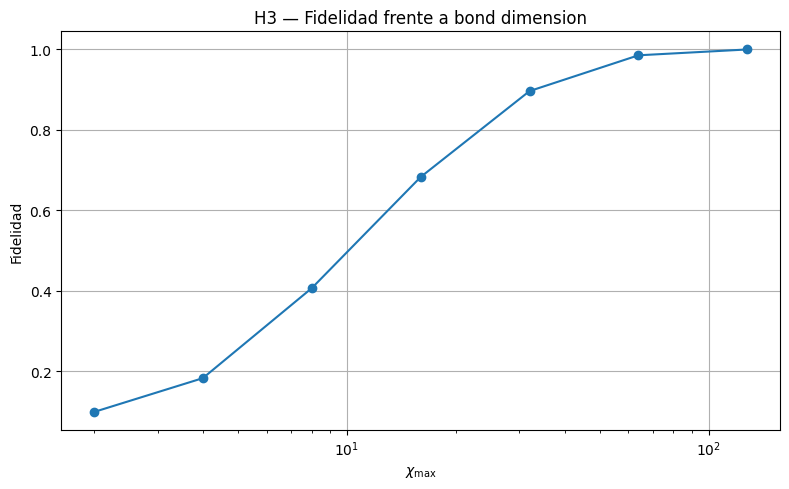

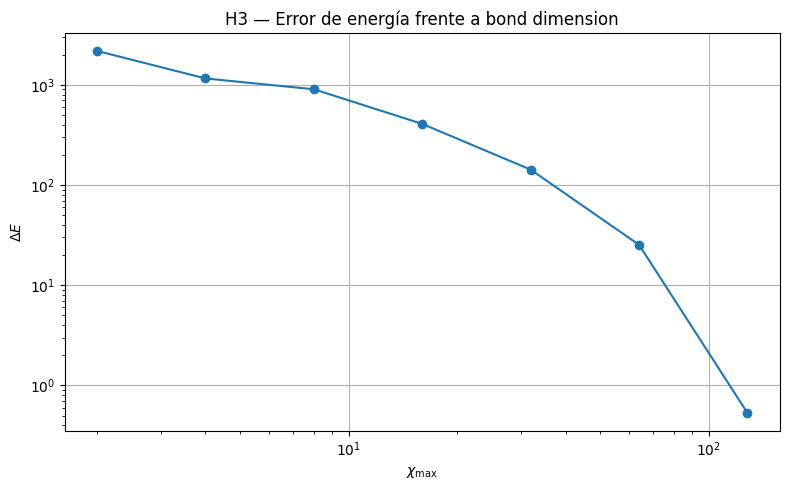

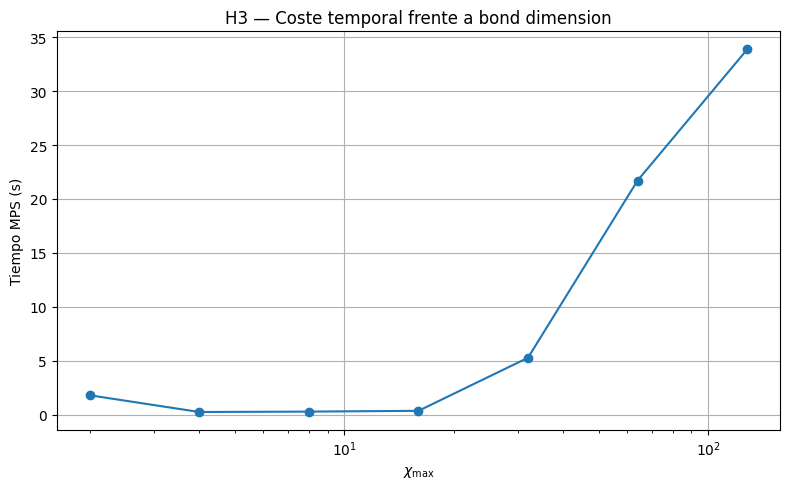

In [20]:
if RUN_TRUNCATION:
    plt.figure(figsize=(8, 5))
    plt.semilogx(
        truncation["chi_limit"],
        truncation["fidelity"],
        marker="o",
    )
    plt.xlabel(r"$\chi_{\max}$")
    plt.ylabel("Fidelidad")
    plt.title("H3 — Fidelidad frente a bond dimension")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "01_fidelity_vs_chi.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.loglog(
        truncation["chi_limit"],
        np.maximum(truncation["energy_error"], 1e-16),
        marker="o",
    )
    plt.xlabel(r"$\chi_{\max}$")
    plt.ylabel(r"$\Delta E$")
    plt.title("H3 — Error de energía frente a bond dimension")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "02_energy_error_vs_chi.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.semilogx(
        truncation["chi_limit"],
        truncation["time_mps_s"],
        marker="o",
    )
    plt.xlabel(r"$\chi_{\max}$")
    plt.ylabel("Tiempo MPS (s)")
    plt.title("H3 — Coste temporal frente a bond dimension")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "03_time_vs_chi.png",
        dpi=220
    )
    plt.show()


# 8. Experimento B — profundidad QAOA

Se varía:

$$
p\in\{1,2,3,4,5\}.
$$

Se registra:

$$
p,\quad
\chi_{\rm real},\quad
t_{\rm MPS}.
$$

### H4

$$
\boxed{
\text{La profundidad puede incrementar la complejidad tensorial.}
}
$$

Para reforzar la hipótesis, se comparará además el perfil de entrelazamiento en instancias pequeñas.


In [21]:
def depth_experiment(
    n_customers,
    gamma,
    beta,
    depths,
    max_bond=128,
    cutoff=1e-10,
):
    _, _, _, _, ising_op, _ = make_tsp_instance(n_customers)
    z_terms, zz_terms = extract_ising_terms(ising_op)

    rows = []

    for p in depths:
        print(f"Ejecutando profundidad p={p}")

        t0 = time.perf_counter()

        circuit = build_qaoa_mps(
            ising_op.num_qubits,
            z_terms,
            zz_terms,
            gamma,
            beta,
            depth=p,
            max_bond=max_bond,
            cutoff=cutoff,
        )

        elapsed = time.perf_counter() - t0
        bonds = mps_bond_profile(circuit)

        chi_real = int(bonds.max()) if len(bonds) else 1
        mps_elements = mps_tensor_elements(circuit)
        sv_amplitudes = statevector_amplitudes(ising_op.num_qubits)

        rows.append({
            "clientes": n_customers,
            "qubits": ising_op.num_qubits,
            "depth": p,
            "chi_limit": max_bond,
            "chi_real": chi_real,
            "chi_mean": float(bonds.mean()) if len(bonds) else 1.0,
            "mps_tensor_elements": mps_elements,
            "statevector_amplitudes": sv_amplitudes,
            "compression_ratio":
                representation_compression_ratio(
                    ising_op.num_qubits,
                    mps_elements
                ),
            "mps_fraction_percent":
                100.0 * mps_elements / sv_amplitudes,
            "mps_memory_GB_est":
                mps_estimated_memory_gb(circuit),
            "time_mps_s": elapsed,
        })

        del circuit
        gc.collect()

    return pd.DataFrame(rows)


if RUN_DEPTH:
    depth_results = depth_experiment(
        DEPTH_N,
        GAMMA,
        BETA,
        DEPTHS,
        DEPTH_MAX_BOND,
    )

    display(depth_results)
    depth_results.to_csv(
        RESULTS / "04_depth.csv",
        index=False
    )


Ejecutando profundidad p=1
Ejecutando profundidad p=2
Ejecutando profundidad p=3
Ejecutando profundidad p=4
Ejecutando profundidad p=5


,clientes,qubits,depth,chi_limit,chi_real,chi_mean,mps_tensor_elements,statevector_amplitudes,compression_ratio,mps_fraction_percent,mps_memory_GB_est,time_mps_s
0,3,9,1,128,16,7.5,1192,512,0.42953,232.8125,0.000018,0.094017
1,3,9,2,128,16,7.5,1192,512,0.42953,232.8125,0.000018,0.134576
2,3,9,3,128,16,7.5,1192,512,0.42953,232.8125,0.000018,0.189936
3,3,9,4,128,16,7.5,1192,512,0.42953,232.8125,0.000018,0.309561
4,3,9,5,128,16,7.5,1192,512,0.42953,232.8125,0.000018,0.373647


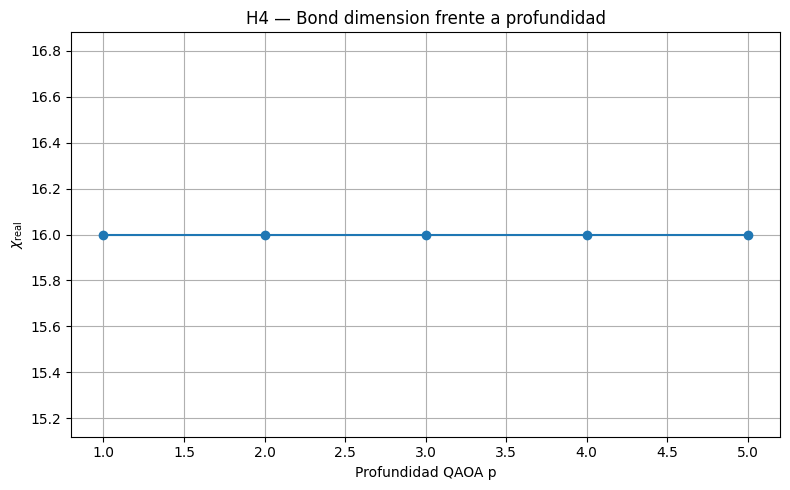

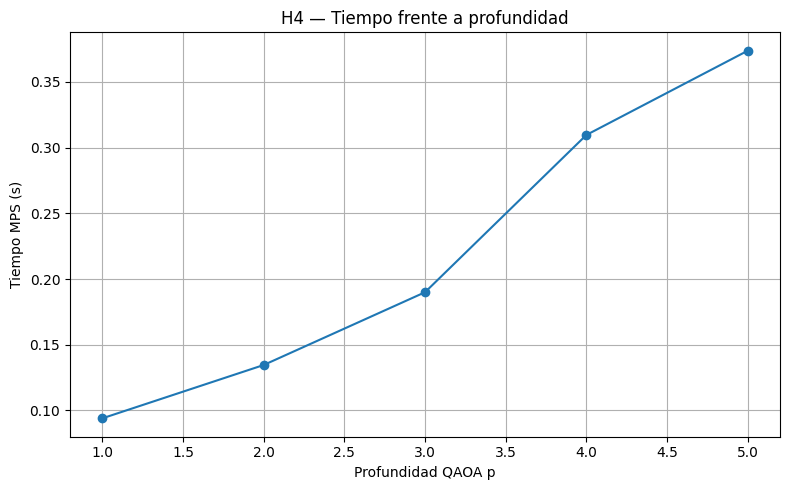

In [22]:
if RUN_DEPTH:
    plt.figure(figsize=(8, 5))
    plt.plot(
        depth_results["depth"],
        depth_results["chi_real"],
        marker="o",
    )
    plt.xlabel("Profundidad QAOA p")
    plt.ylabel(r"$\chi_{\rm real}$")
    plt.title("H4 — Bond dimension frente a profundidad")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "04_chi_vs_depth.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        depth_results["depth"],
        depth_results["time_mps_s"],
        marker="o",
    )
    plt.xlabel("Profundidad QAOA p")
    plt.ylabel("Tiempo MPS (s)")
    plt.title("H4 — Tiempo frente a profundidad")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "05_time_vs_depth.png",
        dpi=220
    )
    plt.show()


# 9. Experimento C — escalabilidad MPS

Para el encoding posición-tiempo utilizado:

$$
n_q\propto N^2.
$$

El statevector requiere:

$$
M_{\rm SV}
=
16\,2^{n_q}\ {\rm bytes}.
$$

La MPS se ejecuta directamente y se mide:

$$
t_{\rm MPS},
\qquad
\chi_{\rm real}.
$$

Para tamaños que superarían el límite exacto **no se genera ningún statevector**.

### H1

La evidencia se obtiene combinando:

1. crecimiento teórico exponencial de $M_{\rm SV}$;
2. crecimiento observado del tiempo MPS;
3. crecimiento observado de $\chi$;
4. ausencia de necesidad de construir el statevector para tamaños mayores.


In [23]:
def scaling_experiment(
    customer_sizes,
    gamma,
    beta,
    depth,
    max_bond=128,
    cutoff=1e-10,
):
    rows = []

    for N in customer_sizes:
        _, _, _, _, ising_op, _ = make_tsp_instance(N)
        z_terms, zz_terms = extract_ising_terms(ising_op)
        nq = ising_op.num_qubits

        print(
            f"N={N} | qubits={nq} | "
            f"SV teórico={memory_statevector_gb(nq):.4g} GiB"
        )

        t0 = time.perf_counter()

        circuit = build_qaoa_mps(
            nq,
            z_terms,
            zz_terms,
            gamma,
            beta,
            depth=depth,
            max_bond=max_bond,
            cutoff=cutoff,
        )

        elapsed = time.perf_counter() - t0
        bonds = mps_bond_profile(circuit)

        mps_elements = mps_tensor_elements(circuit)
        sv_amplitudes = statevector_amplitudes(nq)
        mps_memory = mps_estimated_memory_gb(circuit)

        rows.append({
            "clientes": N,
            "qubits": nq,

            # Statevector: representación densa.
            "statevector_amplitudes": sv_amplitudes,
            "statevector_memory_GB": memory_statevector_gb(nq),

            # MPS: coeficientes de los tensores.
            "mps_tensor_elements": mps_elements,
            "mps_memory_GB_est": mps_memory,

            # Comparación de representaciones.
            "compression_ratio":
                representation_compression_ratio(
                    nq,
                    mps_elements
                ),
            "mps_fraction_percent":
                100.0 * mps_elements / sv_amplitudes,

            # Complejidad tensorial.
            "chi_max": int(bonds.max()) if len(bonds) else 1,
            "chi_mean": float(bonds.mean()) if len(bonds) else 1.0,

            # Coste temporal.
            "mps_time_s": elapsed,

            "depth": depth,
            "chi_limit": max_bond,
        })

        print(
            f"  chi_max={rows[-1]['chi_max']} | "
            f"N_MPS={mps_elements:,} | "
            f"N_SV={sv_amplitudes:,} | "
            f"ratio={rows[-1]['compression_ratio']:.4g} | "
            f"frac={rows[-1]['mps_fraction_percent']:.4g}% | "
            f"t={elapsed:.3f}s"
        )

        del circuit
        gc.collect()

    return pd.DataFrame(rows)


if RUN_SCALING:
    scaling = scaling_experiment(
        SCALING_SIZES,
        GAMMA,
        BETA,
        SCALING_DEPTH,
        SCALING_MAX_BOND,
    )

    display(scaling)

    scaling.to_csv(
        RESULTS / "06_scaling_mps.csv",
        index=False
    )


N=2 | qubits=4 | SV teórico=2.384e-07 GiB
  chi_max=4 | N_MPS=40 | N_SV=16 | ratio=0.4 | frac=250% | t=0.012s
N=3 | qubits=9 | SV teórico=7.629e-06 GiB
  chi_max=16 | N_MPS=1,192 | N_SV=512 | ratio=0.4295 | frac=232.8% | t=0.076s
N=4 | qubits=16 | SV teórico=0.0009766 GiB
  chi_max=128 | N_MPS=106,152 | N_SV=65,536 | ratio=0.6174 | frac=162% | t=11.614s
N=5 | qubits=25 | SV teórico=0.5 GiB
  chi_max=128 | N_MPS=404,136 | N_SV=33,554,432 | ratio=83.03 | frac=1.204% | t=133.915s
N=6 | qubits=36 | SV teórico=1024 GiB
  chi_max=128 | N_MPS=764,584 | N_SV=68,719,476,736 | ratio=8.988e+04 | frac=0.001113% | t=506.086s


,clientes,qubits,statevector_amplitudes,statevector_memory_GB,mps_tensor_elements,mps_memory_GB_est,compression_ratio,mps_fraction_percent,chi_max,chi_mean,mps_time_s,depth,chi_limit
0,2,4,16,2.384186e-07,40,5.960464e-07,0.400000,250.000000,4,2.666667,0.012452,1,128
1,3,9,512,7.629395e-06,1192,1.776218e-05,0.429530,232.812500,16,7.500000,0.075538,1,128
2,4,16,65536,9.765625e-04,106152,1.581788e-03,0.617379,161.975098,128,41.866667,11.614077,1,128
3,5,25,33554432,5.000000e-01,404136,6.022096e-03,83.027575,1.204419,128,74.500000,133.915142,1,128
4,6,36,68719476736,1.024000e+03,764584,1.139319e-02,89878.256328,0.001113,128,91.314286,506.085978,1,128


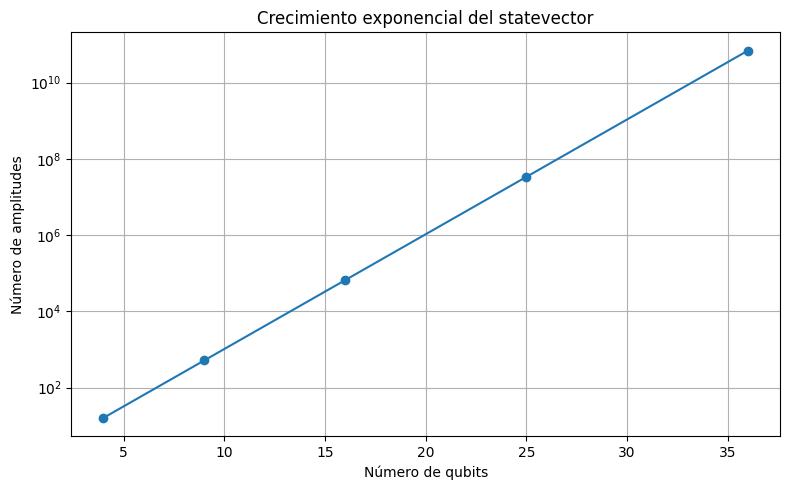

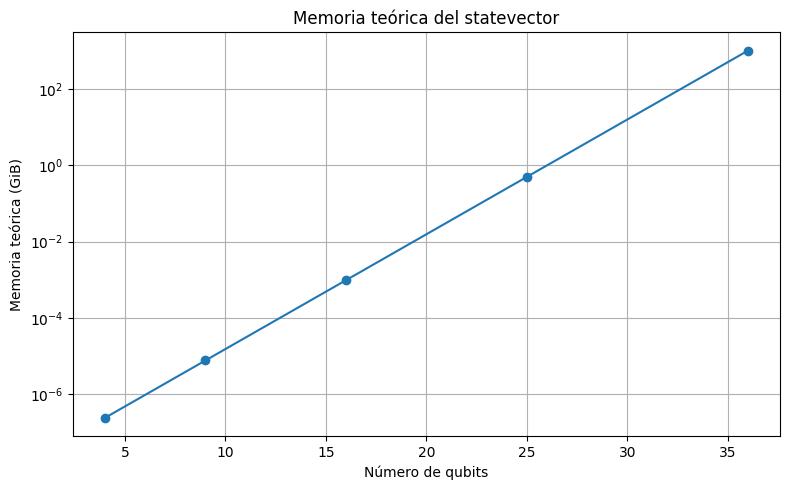

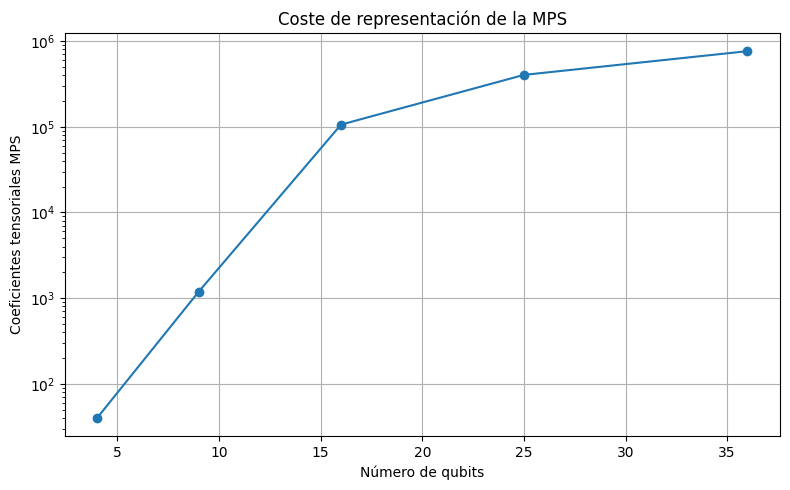

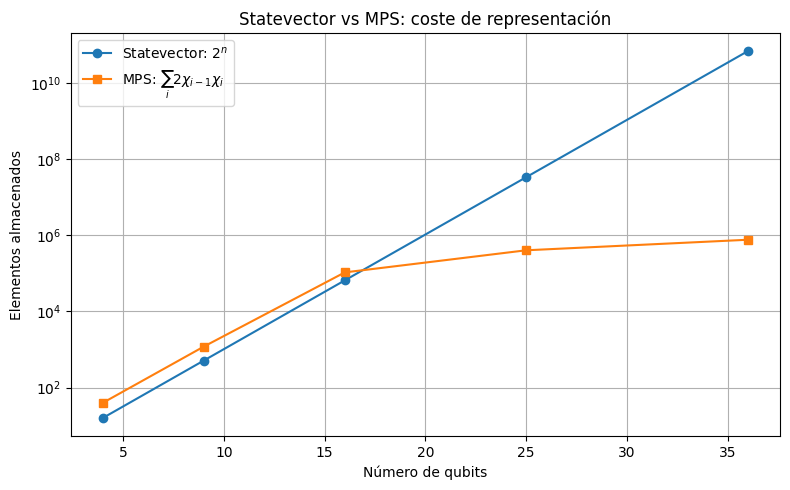

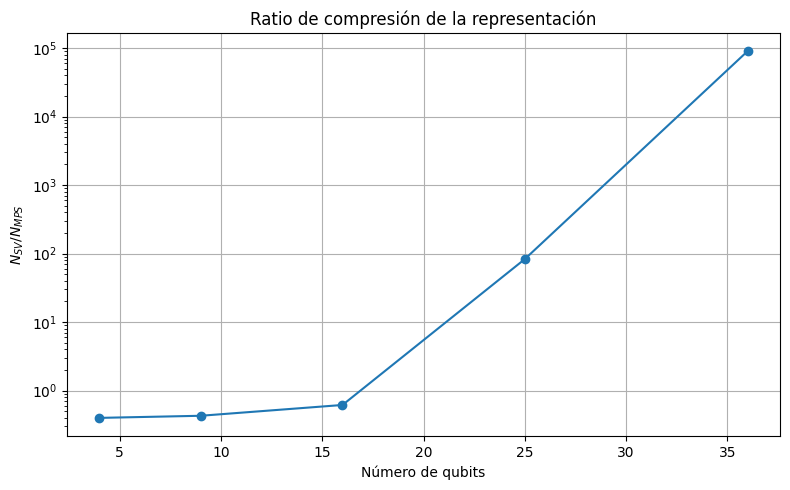

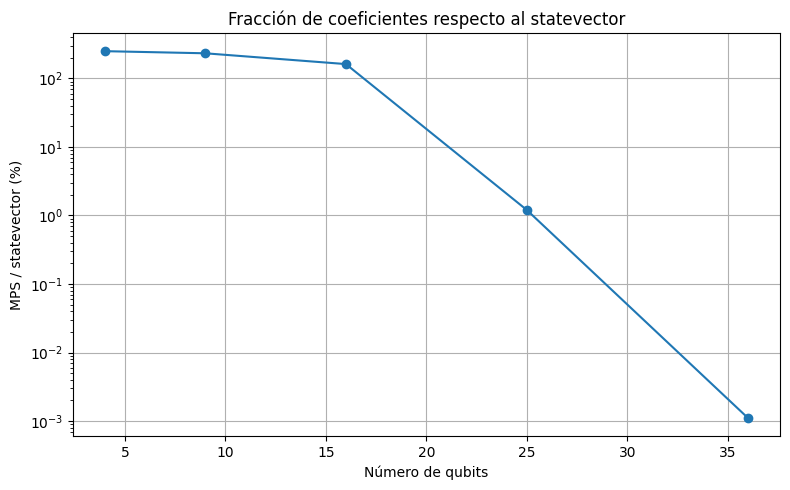

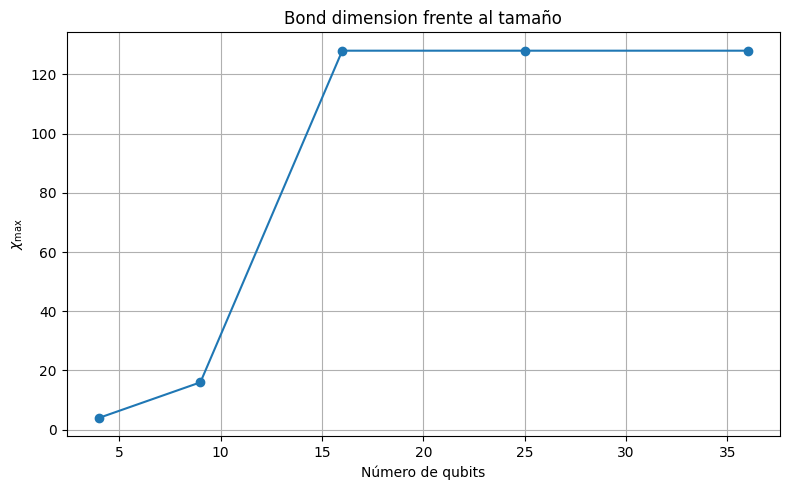

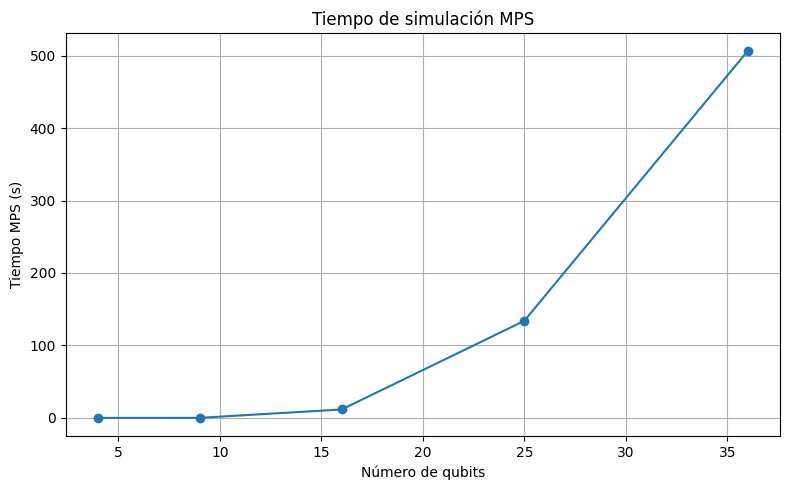

In [27]:
if RUN_SCALING:
    # ---------------------------------------------------------------
    # 1. Statevector: amplitudes y memoria
    # ---------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.semilogy(
        scaling["qubits"],
        scaling["statevector_amplitudes"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel("Número de amplitudes")
    plt.title("Crecimiento exponencial del statevector")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "06_statevector_amplitudes.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.semilogy(
        scaling["qubits"],
        scaling["statevector_memory_GB"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel("Memoria teórica (GiB)")
    plt.title("Memoria teórica del statevector")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "06_statevector_memory.png",
        dpi=220
    )
    plt.show()

    # ---------------------------------------------------------------
    # 2. MPS: coeficientes tensoriales y memoria estimada
    # ---------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.semilogy(
        scaling["qubits"],
        scaling["mps_tensor_elements"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel("Coeficientes tensoriales MPS")
    plt.title("Coste de representación de la MPS")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "07_mps_tensor_elements.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.semilogy(
        scaling["qubits"],
        scaling["statevector_amplitudes"],
        marker="o",
        label="Statevector: $2^n$",
    )
    plt.semilogy(
        scaling["qubits"],
        scaling["mps_tensor_elements"],
        marker="s",
        label="MPS: $\sum_i 2\chi_{i-1}\chi_i$",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel("Elementos almacenados")
    plt.title("Statevector vs MPS: coste de representación")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "08_statevector_vs_mps_representation.png",
        dpi=220
    )
    plt.show()

    # ---------------------------------------------------------------
    # 3. Compresión
    # ---------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.semilogy(
        scaling["qubits"],
        scaling["compression_ratio"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel(r"$N_{SV}/N_{MPS}$")
    plt.title("Ratio de compresión de la representación")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "09_compression_ratio.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.semilogy(
        scaling["qubits"],
        scaling["mps_fraction_percent"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel("MPS / statevector (%)")
    plt.title("Fracción de coeficientes respecto al statevector")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "10_mps_fraction_percent_vs_qubits.png",
        dpi=220
    )
    plt.show()

    # ---------------------------------------------------------------
    # 4. Bond dimension y tiempo
    # ---------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(
        scaling["qubits"],
        scaling["chi_max"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel(r"$\chi_{\max}$")
    plt.title("Bond dimension frente al tamaño")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "11_chi_vs_qubits.png",
        dpi=220
    )
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        scaling["qubits"],
        scaling["mps_time_s"],
        marker="o",
    )
    plt.xlabel("Número de qubits")
    plt.ylabel("Tiempo MPS (s)")
    plt.title("Tiempo de simulación MPS")
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "12_mps_time_vs_qubits.png",
        dpi=220
    )
    plt.show()


# 10. Experimento G — escalabilidad exacta vs. MPS

Este experimento proporciona la comparación temporal más directa para H1.

Para cada tamaño seguro se ejecutan:

- QAOA con `Statevector`;
- QAOA-MPS.

El statevector se bloquea automáticamente cuando:

$$
n_q > \texttt{EXACT\_MAX\_QUBITS}.
$$

Esto evita repetir el problema que causaba la muerte del kernel.


In [28]:
def exact_scaling_experiment(
    customer_sizes,
    gamma,
    beta,
    depth,
    max_bond=128,
):
    rows = []

    for N in customer_sizes:
        _, _, _, _, ising_op, _ = make_tsp_instance(N)
        z_terms, zz_terms = extract_ising_terms(ising_op)
        nq = ising_op.num_qubits

        # -----------------------------------------------------------
        # MPS
        # -----------------------------------------------------------
        t0 = time.perf_counter()

        circuit = build_qaoa_mps(
            nq,
            z_terms,
            zz_terms,
            gamma,
            beta,
            depth=depth,
            max_bond=max_bond,
            cutoff=1e-10,
        )

        t_mps = time.perf_counter() - t0

        bonds = mps_bond_profile(circuit)
        chi = int(bonds.max()) if len(bonds) else 1
        mps_elements = mps_tensor_elements(circuit)

        # -----------------------------------------------------------
        # Exacto solamente si está dentro del límite
        # -----------------------------------------------------------
        t_sv = np.nan
        speedup = np.nan

        if nq <= EXACT_MAX_QUBITS:
            t0 = time.perf_counter()
            _ = exact_state(
                ising_op,
                gamma,
                beta,
                depth
            )
            t_sv = time.perf_counter() - t0

            if t_mps > 0:
                speedup = t_sv / t_mps

        rows.append({
            "clientes": N,
            "qubits": nq,

            "statevector_amplitudes":
                statevector_amplitudes(nq),

            "statevector_memory_GB":
                memory_statevector_gb(nq),

            "mps_tensor_elements":
                mps_elements,

            "mps_memory_GB_est":
                mps_estimated_memory_gb(circuit),

            "compression_ratio":
                representation_compression_ratio(
                    nq,
                    mps_elements
                ),

            "mps_fraction_percent":
                100.0 * mps_elements / statevector_amplitudes(nq),

            "time_statevector_s": t_sv,
            "time_mps_s": t_mps,
            "speedup_sv_over_mps": speedup,

            "chi_max": chi,
            "chi_mean":
                float(bonds.mean()) if len(bonds) else 1.0,

            "depth": depth,
            "chi_limit": max_bond,
        })

        print(
            f"N={N} | q={nq} | "
            f"SV={t_sv if not np.isnan(t_sv) else 'SKIP'} | "
            f"MPS={t_mps:.4f}s | "
            f"chi={chi} | "
            f"ratio={rows[-1]['compression_ratio']:.4g}"
        )

        del circuit
        gc.collect()

    return pd.DataFrame(rows)


if RUN_EXACT_SCALING:
    exact_scaling = exact_scaling_experiment(
        SCALING_SIZES,
        GAMMA,
        BETA,
        SCALING_DEPTH,
        SCALING_MAX_BOND,
    )

    display(exact_scaling)

    exact_scaling.to_csv(
        RESULTS / "07_exact_vs_mps_scaling.csv",
        index=False
    )


N=2 | q=4 | SV=0.0023642060114070773 | MPS=0.0133s | chi=4 | ratio=0.4
N=3 | q=9 | SV=0.005719806998968124 | MPS=0.0642s | chi=16 | ratio=0.4295
N=4 | q=16 | SV=0.18074131902540103 | MPS=11.6141s | chi=128 | ratio=0.6174
N=5 | q=25 | SV=SKIP | MPS=130.4501s | chi=128 | ratio=83.03
N=6 | q=36 | SV=SKIP | MPS=529.5478s | chi=128 | ratio=8.988e+04


,clientes,qubits,statevector_amplitudes,statevector_memory_GB,mps_tensor_elements,mps_memory_GB_est,compression_ratio,mps_fraction_percent,time_statevector_s,time_mps_s,speedup_sv_over_mps,chi_max,chi_mean,depth,chi_limit
0,2,4,16,2.384186e-07,40,5.960464e-07,0.400000,250.000000,0.002364,0.013260,0.178290,4,2.666667,1,128
1,3,9,512,7.629395e-06,1192,1.776218e-05,0.429530,232.812500,0.005720,0.064154,0.089158,16,7.500000,1,128
2,4,16,65536,9.765625e-04,106152,1.581788e-03,0.617379,161.975098,0.180741,11.614052,0.015562,128,41.866667,1,128
3,5,25,33554432,5.000000e-01,404136,6.022096e-03,83.027575,1.204419,NaN,130.450051,NaN,128,74.500000,1,128
4,6,36,68719476736,1.024000e+03,764584,1.139319e-02,89878.256328,0.001113,NaN,529.547775,NaN,128,91.314286,1,128


# 11. Análisis específico del coste de representación

Este experimento convierte la diferencia conceptual entre statevector y MPS en una
métrica cuantitativa directamente utilizable en la memoria del TFM.

Para un statevector de $n$ qubits:

$$
N_{\mathrm{SV}}=2^n.
$$

Para una MPS de qubits con enlaces $\chi_1,\ldots,\chi_{n-1}$:

$$
N_{\mathrm{MPS}}
=
\sum_{i=1}^{n}
2\chi_{i-1}\chi_i,
\qquad
\chi_0=\chi_n=1.
$$

Por tanto, se define el ratio de compresión de la representación como

$$
R_{\mathrm{comp}}
=
\frac{N_{\mathrm{SV}}}{N_{\mathrm{MPS}}}.
$$

Esta magnitud **no representa una compresión de memoria física exacta**: la MPS
incluye estructuras y metadatos adicionales. Se interpreta como una comparación
del número de coeficientes escalares necesarios para describir ambas
representaciones. La memoria teórica de los coeficientes se estima además
suponiendo `complex128` (16 bytes por coeficiente).

La distinción es importante: una MPS no almacena las $2^n$ amplitudes físicas
individuales, sino un conjunto de tensores que las representa implícitamente.


In [29]:
def build_representation_report(data):
    """Construye una tabla compacta para la memoria del TFM."""
    required = [
        "clientes",
        "qubits",
        "statevector_amplitudes",
        "mps_tensor_elements",
        "compression_ratio",
        "mps_fraction_percent",
        "chi_max",
        "mps_memory_GB_est",
        "statevector_memory_GB",
    ]

    available = [c for c in required if c in data.columns]

    report = data[available].copy()

    report["compression_ratio"] = report[
        "compression_ratio"
    ].astype(float)

    return report


if RUN_REPRESENTATION_REPORT:
    # Preferimos el experimento MPS de escalabilidad porque puede llegar
    # a tamaños donde el statevector exacto ya no es viable.
    if "scaling" in globals() and not scaling.empty:
        representation_report = build_representation_report(
            scaling
        )

        print("=" * 80)
        print("ANÁLISIS DEL COSTE DE REPRESENTACIÓN")
        print("=" * 80)

        display(
            representation_report.style.format({
                "statevector_amplitudes": "{:,.0f}",
                "mps_tensor_elements": "{:,.0f}",
                "compression_ratio": "{:,.3g}",
                "mps_fraction_percent": "{:.5g}",
                "statevector_memory_GB": "{:.5g}",
                "mps_memory_GB_est": "{:.5g}",
            })
        )

        representation_report.to_csv(
            RESULTS / "13_representation_cost.csv",
            index=False
        )

        print()
        print(
            "Interpretación: un ratio R_comp > 1 indica que la MPS "
            "utiliza menos coeficientes tensoriales que el número de "
            "amplitudes del statevector."
        )
    else:
        print(
            "No existe todavía el resultado de escalabilidad. "
            "Ejecuta RUN_SCALING = True."
        )


ANÁLISIS DEL COSTE DE REPRESENTACIÓN


,clientes,qubits,statevector_amplitudes,mps_tensor_elements,compression_ratio,mps_fraction_percent,chi_max,mps_memory_GB_est,statevector_memory_GB
0,2,4,16,40,0.4,250,4,5.9605e-07,2.3842e-07
1,3,9,512,"1,192",0.43,232.81,16,1.7762e-05,7.6294e-06
2,4,16,"65,536","106,152",0.617,161.98,128,0.0015818,0.00097656
3,5,25,"33,554,432","404,136",83,1.2044,128,0.0060221,0.5
4,6,36,"68,719,476,736","764,584",8.99e+04,0.0011126,128,0.011393,1024



Interpretación: un ratio R_comp > 1 indica que la MPS utiliza menos coeficientes tensoriales que el número de amplitudes del statevector.


# 12. Escala teórica de la representación exacta

Como referencia independiente de los experimentos, se muestra el crecimiento teórico
del statevector en `complex128`. Cada amplitud ocupa 16 bytes, por lo que:

$$
M_{SV}=16\cdot2^n\ \text{bytes}.
$$

Esta tabla no ejecuta ningún statevector: solamente calcula el coste de almacenamiento
teórico. Es útil para mostrar por qué el límite práctico de la referencia exacta aparece
mucho antes de los tamaños para los que una MPS puede seguir siendo manejable.


,qubits,statevector_amplitudes,memory_GiB
0,10,"1,024",1.52588e-05
1,11,"2,048",3.05176e-05
2,12,"4,096",6.10352e-05
3,13,"8,192",0.00012207
4,14,"16,384",0.000244141
5,15,"32,768",0.000488281
6,16,"65,536",0.000976562
7,17,"131,072",0.00195312
8,18,"262,144",0.00390625
9,19,"524,288",0.0078125


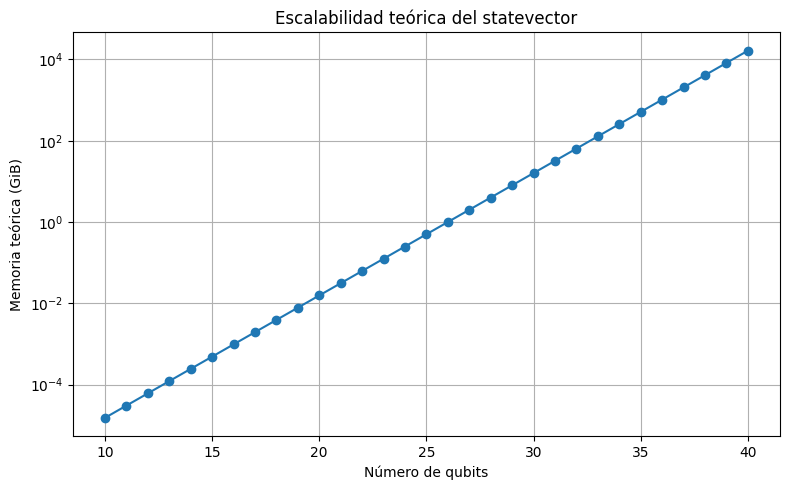

In [30]:
def theoretical_statevector_table(
    n_min=10,
    n_max=40,
):
    rows = []

    for n in range(n_min, n_max + 1):
        amplitudes = statevector_amplitudes(n)
        memory_gib = memory_statevector_gb(n)

        rows.append({
            "qubits": n,
            "statevector_amplitudes": amplitudes,
            "memory_GiB": memory_gib,
        })

    return pd.DataFrame(rows)


theoretical_sv = theoretical_statevector_table()

display(
    theoretical_sv.style.format({
        "statevector_amplitudes": "{:,.0f}",
        "memory_GiB": "{:.6g}",
    })
)

theoretical_sv.to_csv(
    RESULTS / "14_theoretical_statevector_scaling.csv",
    index=False
)

plt.figure(figsize=(8, 5))
plt.semilogy(
    theoretical_sv["qubits"],
    theoretical_sv["memory_GiB"],
    marker="o",
)
plt.xlabel("Número de qubits")
plt.ylabel("Memoria teórica (GiB)")
plt.title("Escalabilidad teórica del statevector")
plt.grid()
plt.tight_layout()
plt.savefig(
    FIGURES / "13_theoretical_statevector_scaling.png",
    dpi=220
)
plt.show()


# 13. Experimento D — entropía de entrelazamiento

Para una referencia exacta pequeña calculamos, para cada corte \(b\):

$$
S_b=-\sum_\alpha s_\alpha^2\log(s_\alpha^2).
$$

Y utilizamos:

$$
\boxed{S_b\leq\log\chi_b}.
$$

El experimento permite comprobar la cadena:

$$
\boxed{
\text{entrelazamiento}
\rightarrow
\chi
\rightarrow
\text{coste MPS}.
}
$$

Se recomienda mantener este experimento en \(N=3\), porque requiere el estado exacto.


In [31]:
def exact_entropy_profile(state, n_qubits):
    tensor = np.asarray(state).reshape([2] * n_qubits)
    entropies = []

    for cut in range(1, n_qubits):
        matrix = tensor.reshape(
            2 ** cut,
            2 ** (n_qubits - cut)
        )

        s = np.linalg.svd(
            matrix,
            compute_uv=False
        )

        p = s ** 2
        p = p[p > 1e-15]
        p = p / p.sum()

        entropies.append(
            float(-np.sum(p * np.log(p)))
        )

    return np.asarray(entropies)


def entropy_depth_experiment(
    n_customers,
    gamma,
    beta,
    depths,
):
    _, _, _, _, ising_op, _ = make_tsp_instance(n_customers)
    rows = []

    for p in depths:
        state, _ = exact_run(
            ising_op,
            gamma,
            beta,
            p
        )

        S = exact_entropy_profile(
            state,
            ising_op.num_qubits
        )

        for cut, entropy_value in enumerate(S, start=1):
            rows.append({
                "clientes": n_customers,
                "qubits": ising_op.num_qubits,
                "depth": p,
                "cut": cut,
                "entropy": entropy_value,
            })

    return pd.DataFrame(rows)


if RUN_ENTANGLEMENT:
    entropy_results = entropy_depth_experiment(
        ENTANGLEMENT_N,
        GAMMA,
        BETA,
        ENTANGLEMENT_DEPTHS,
    )

    display(entropy_results)

    entropy_results.to_csv(
        RESULTS / "08_entanglement.csv",
        index=False
    )


,clientes,qubits,depth,cut,entropy
0,3,9,1,1,0.687073
1,3,9,1,2,1.353210
2,3,9,1,3,1.807316
3,3,9,1,4,2.326650
4,3,9,1,5,2.368705
5,3,9,1,6,1.885073
6,3,9,1,7,1.345571
7,3,9,1,8,0.685593
8,3,9,2,1,0.692888
9,3,9,2,2,1.337650


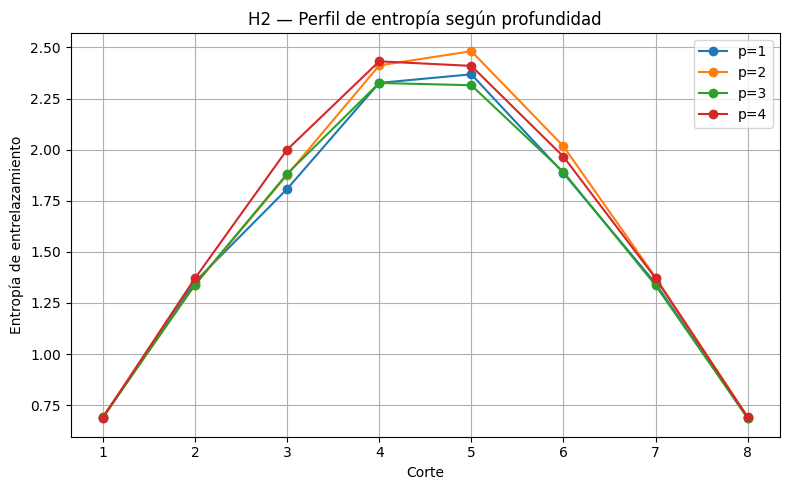

In [32]:
if RUN_ENTANGLEMENT:
    plt.figure(figsize=(8, 5))

    for p in sorted(entropy_results["depth"].unique()):
        data = entropy_results[
            entropy_results["depth"] == p
        ]
        plt.plot(
            data["cut"],
            data["entropy"],
            marker="o",
            label=f"p={p}",
        )

    plt.xlabel("Corte")
    plt.ylabel("Entropía de entrelazamiento")
    plt.title("H2 — Perfil de entropía según profundidad")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "09_entropy_depth.png",
        dpi=220
    )
    plt.show()


# 14. Experimento E — régimen de fallo

Una conclusión científica rigurosa debe identificar también cuándo la aproximación MPS deja de ser ventajosa.

Se busca un régimen en el que:

$$
F\not\simeq1
$$

para $\chi$ pequeñas y donde mantener:

$$
F\geq0.99
$$

requiera aumentar significativamente $\chi$.

### Interpretación

- Si una fidelidad alta se alcanza con $\chi$ moderada, el régimen es favorable.
- Si la fidelidad mejora lentamente al aumentar $\chi$, aparece un régimen desfavorable.
- Si $\chi$ se aproxima al máximo posible, la compresión MPS pierde parte de su ventaja.


In [33]:
if RUN_FAILURE_REGIME:
    failure = truncation_experiment(
        FAILURE_N,
        GAMMA,
        BETA,
        FAILURE_DEPTH,
        FAILURE_CHIS,
    )

    display(failure)

    failure.to_csv(
        RESULTS / "10_failure_regime.csv",
        index=False
    )


Ejecutando truncación: chi=2
  normSV=1.000000 | normMPS=0.011416 | overlap=0.0664767050 | F=0.0044191523 | dE=2.958e+03 | chi_real=2 | t=0.528s
Ejecutando truncación: chi=4
  normSV=1.000000 | normMPS=0.025745 | overlap=0.0789198516 | F=0.0062283430 | dE=3.408e+03 | chi_real=4 | t=0.523s
Ejecutando truncación: chi=8
  normSV=1.000000 | normMPS=0.069132 | overlap=0.1490584351 | F=0.0222184171 | dE=2.544e+03 | chi_real=8 | t=0.588s
Ejecutando truncación: chi=16
  normSV=1.000000 | normMPS=0.163001 | overlap=0.2876649826 | F=0.0827511422 | dE=1.921e+03 | chi_real=16 | t=0.826s
Ejecutando truncación: chi=32
  normSV=1.000000 | normMPS=0.367571 | overlap=0.5393207242 | F=0.2908668435 | dE=1.216e+03 | chi_real=32 | t=11.136s
Ejecutando truncación: chi=64
  normSV=1.000000 | normMPS=0.713225 | overlap=0.8458325488 | F=0.7154327005 | dE=4.826e+02 | chi_real=64 | t=47.711s
Ejecutando truncación: chi=128
  normSV=1.000000 | normMPS=0.963202 | overlap=0.9861099960 | F=0.9724129242 | dE=7.090e+01

,clientes,qubits,depth,chi_limit,chi_real,mps_tensor_elements,statevector_amplitudes,compression_ratio,mps_fraction_percent,mps_memory_GB_est,...,norm_MPS,overlap,fidelity,infidelity,energy_reference,energy_mps,energy_error,time_mps_s,time_exact_s,statevector_memory_GB
0,4,16,2,2,2,120,65536,546.133333,0.183105,0.000002,...,0.011416,0.066477,0.004419,0.995581,1438.529762,4396.928060,2958.398298,0.528476,0.317463,0.000977
1,4,16,2,4,4,424,65536,154.566038,0.646973,0.000006,...,0.025745,0.078920,0.006228,0.993772,1438.529762,4846.895115,3408.365353,0.522867,0.317463,0.000977
2,4,16,2,8,8,1448,65536,45.259669,2.209473,0.000022,...,0.069132,0.149058,0.022218,0.977782,1438.529762,3982.797698,2544.267936,0.588358,0.317463,0.000977
3,4,16,2,16,16,4776,65536,13.721943,7.287598,0.000071,...,0.163001,0.287665,0.082751,0.917249,1438.529762,3359.942446,1921.412684,0.826299,0.317463,0.000977
4,4,16,2,32,32,15016,65536,4.364411,22.912598,0.000224,...,0.367571,0.539321,0.290867,0.709133,1438.529762,2654.962931,1216.433169,11.135582,0.317463,0.000977
5,4,16,2,64,64,43688,65536,1.500092,66.662598,0.000651,...,0.713225,0.845833,0.715433,0.284567,1438.529762,1921.169307,482.639545,47.711395,0.317463,0.000977
6,4,16,2,128,128,109224,65536,0.600015,166.662598,0.001628,...,0.963202,0.986110,0.972413,0.027587,1438.529762,1509.430404,70.900642,73.055139,0.317463,0.000977


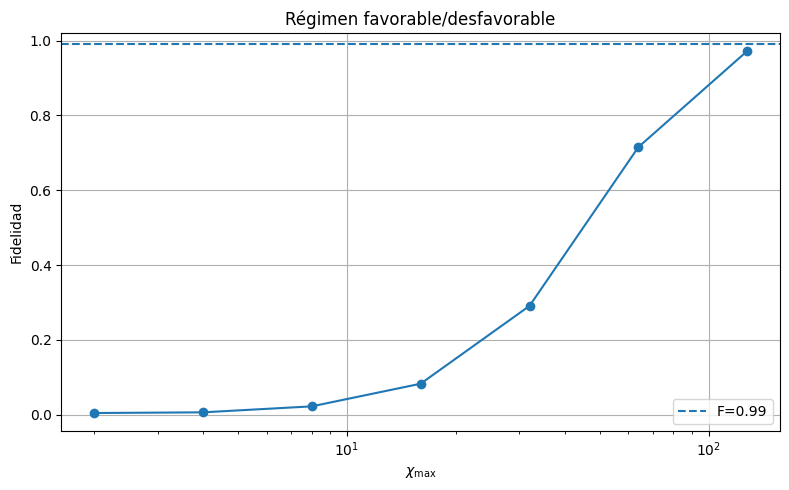

In [34]:
if RUN_FAILURE_REGIME:
    plt.figure(figsize=(8, 5))
    plt.semilogx(
        failure["chi_limit"],
        failure["fidelity"],
        marker="o",
    )
    plt.axhline(
        FIDELITY_THRESHOLD,
        linestyle="--",
        label=f"F={FIDELITY_THRESHOLD}",
    )
    plt.xlabel(r"$\chi_{\max}$")
    plt.ylabel("Fidelidad")
    plt.title("Régimen favorable/desfavorable")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        FIGURES / "10_failure_regime.png",
        dpi=220
    )
    plt.show()


# 15. Experimento F — dependencia con $\gamma$ y $\beta$

Para evitar que las conclusiones dependan de una única pareja de parámetros, se realiza un pequeño barrido:

$$
\gamma\in\{0.15,0.25,0.35,0.45,0.55\}
$$

$$
\beta\in\{0.10,0.20,0.30,0.40\}.
$$

Para cada pareja se calcula la referencia exacta y la aproximación MPS.

Se registran:

$$
F,\quad\Delta E,\quad\chi,\quad t.
$$

Este experimento permite identificar **regímenes favorables y desfavorables** y aporta robustez a H2 y H3.


In [35]:
def parameter_sweep_experiment(
    n_customers,
    gammas,
    betas,
    depth,
    chi,
):
    _, _, _, _, ising_op, _ = make_tsp_instance(n_customers)
    z_terms, zz_terms = extract_ising_terms(ising_op)

    rows = []

    for gamma in gammas:
        for beta in betas:
            print(
                f"gamma={gamma:.3f}, beta={beta:.3f}"
            )

            # Exacto
            reference, t_exact = exact_run(
                ising_op,
                gamma,
                beta,
                depth
            )
            E_ref = energy(reference, ising_op)

            # MPS
            t0 = time.perf_counter()

            circuit = build_qaoa_mps(
                ising_op.num_qubits,
                z_terms,
                zz_terms,
                gamma,
                beta,
                depth=depth,
                max_bond=chi,
                cutoff=0.0,
            )

            t_mps = time.perf_counter() - t0
            approx = mps_to_vector(circuit)

            F = fidelity(reference, approx)
            E_mps = energy(approx, ising_op)

            rows.append({
                "clientes": n_customers,
                "qubits": ising_op.num_qubits,
                "depth": depth,
                "gamma": gamma,
                "beta": beta,
                "chi_limit": chi,
                "chi_real": mps_max_bond(circuit),
                "fidelity": F,
                "infidelity": 1.0 - F,
                "energy_error": abs(E_mps - E_ref),
                "time_mps_s": t_mps,
                "time_exact_s": t_exact,
            })

            del circuit, approx, reference
            gc.collect()

    return pd.DataFrame(rows)


if RUN_PARAMETER_SWEEP:
    parameter_results = parameter_sweep_experiment(
        PARAMETER_N,
        GAMMAS,
        BETAS,
        PARAMETER_DEPTH,
        chi=32,
    )

    display(parameter_results)

    parameter_results.to_csv(
        RESULTS / "11_parameter_sweep.csv",
        index=False
    )


gamma=0.150, beta=0.100
gamma=0.150, beta=0.200
gamma=0.150, beta=0.300
gamma=0.150, beta=0.400
gamma=0.250, beta=0.100
gamma=0.250, beta=0.200
gamma=0.250, beta=0.300
gamma=0.250, beta=0.400
gamma=0.350, beta=0.100
gamma=0.350, beta=0.200
gamma=0.350, beta=0.300
gamma=0.350, beta=0.400
gamma=0.450, beta=0.100
gamma=0.450, beta=0.200
gamma=0.450, beta=0.300
gamma=0.450, beta=0.400
gamma=0.550, beta=0.100
gamma=0.550, beta=0.200
gamma=0.550, beta=0.300
gamma=0.550, beta=0.400


,clientes,qubits,depth,gamma,beta,chi_limit,chi_real,fidelity,infidelity,energy_error,time_mps_s,time_exact_s
0,3,9,2,0.15,0.1,32,16,1.0,4.440892e-16,8.952838e-13,0.210001,0.011835
1,3,9,2,0.15,0.2,32,16,1.0,-8.881784e-16,4.675371e-12,0.136983,0.008328
2,3,9,2,0.15,0.3,32,16,1.0,0.000000e+00,7.389644e-13,0.133920,0.009169
3,3,9,2,0.15,0.4,32,16,1.0,-8.881784e-16,2.359002e-12,0.134561,0.011779
4,3,9,2,0.25,0.1,32,16,1.0,0.000000e+00,5.471179e-12,0.134826,0.011625
5,3,9,2,0.25,0.2,32,16,1.0,-8.881784e-16,4.149570e-12,0.168577,0.009122
6,3,9,2,0.25,0.3,32,16,1.0,-8.881784e-16,8.327561e-12,0.133917,0.008089
7,3,9,2,0.25,0.4,32,16,1.0,4.440892e-16,4.121148e-12,0.164407,0.009023
8,3,9,2,0.35,0.1,32,16,1.0,-4.440892e-16,3.140599e-12,0.139210,0.008591
9,3,9,2,0.35,0.2,32,16,1.0,0.000000e+00,1.818989e-12,0.135975,0.009102


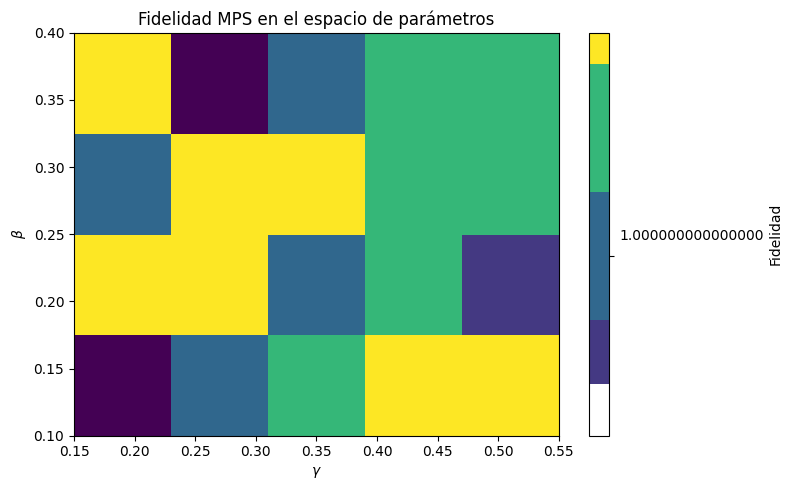

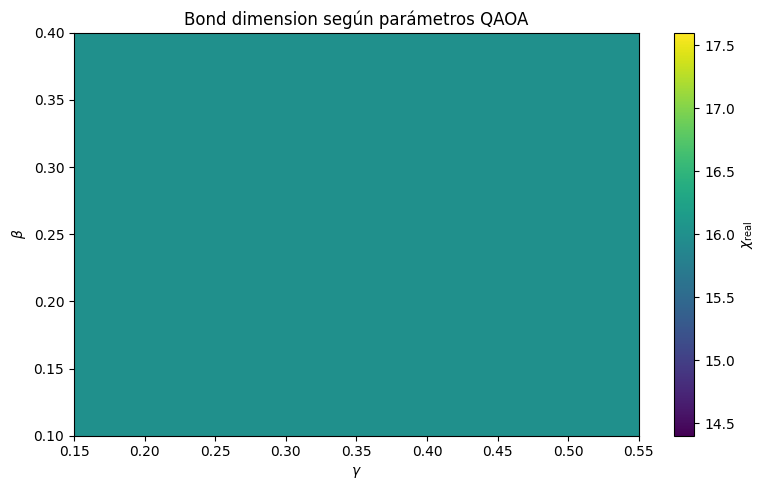

In [36]:
if RUN_PARAMETER_SWEEP:
    pivot_F = parameter_results.pivot(
        index="beta",
        columns="gamma",
        values="fidelity",
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(
        pivot_F.values,
        aspect="auto",
        origin="lower",
        extent=[
            pivot_F.columns.min(),
            pivot_F.columns.max(),
            pivot_F.index.min(),
            pivot_F.index.max(),
        ],
    )
    plt.colorbar(label="Fidelidad")
    plt.xlabel(r"$\gamma$")
    plt.ylabel(r"$\beta$")
    plt.title("Fidelidad MPS en el espacio de parámetros")
    plt.tight_layout()
    plt.savefig(
        FIGURES / "11_parameter_fidelity.png",
        dpi=220
    )
    plt.show()

    pivot_chi = parameter_results.pivot(
        index="beta",
        columns="gamma",
        values="chi_real",
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(
        pivot_chi.values,
        aspect="auto",
        origin="lower",
        extent=[
            pivot_chi.columns.min(),
            pivot_chi.columns.max(),
            pivot_chi.index.min(),
            pivot_chi.index.max(),
        ],
    )
    plt.colorbar(label=r"$\chi_{\rm real}$")
    plt.xlabel(r"$\gamma$")
    plt.ylabel(r"$\beta$")
    plt.title("Bond dimension según parámetros QAOA")
    plt.tight_layout()
    plt.savefig(
        FIGURES / "12_parameter_chi.png",
        dpi=220
    )
    plt.show()


# 16. Análisis automático de las hipótesis

Este bloque no sustituye la interpretación científica, pero ayuda a organizar la evidencia cuantitativa.

## H1 — eficiencia

La evidencia debe considerar conjuntamente:

- memoria teórica del statevector;
- tiempo MPS;
- tiempo exacto cuando sea posible;
- `speedup_sv_over_mps`.

No se debe afirmar que MPS es más rápida solo porque su representación tenga una memoria asintóticamente menor.

## H2 — entrelazamiento

La evidencia debe relacionar:

$$
S_b,\qquad\chi_b,\qquad n_q.
$$

## H3 — truncación

La evidencia principal es la curva:

$$
\chi\rightarrow(F,\Delta E,t).
$$

## H4 — profundidad

La evidencia principal es:

$$
p\rightarrow(\chi,t,S).
$$


In [37]:
def summarize_hypotheses():
    print("=" * 70)
    print("RESUMEN AUTOMÁTICO DE EVIDENCIA")
    print("=" * 70)

    # H3
    trunc_path = RESULTS / "02_truncation.csv"
    if trunc_path.exists():
        tr = pd.read_csv(trunc_path)

        good = tr[
            tr["fidelity"] >= FIDELITY_THRESHOLD
        ]

        print("\nH3 — TRUNCACIÓN")
        if len(good):
            best = good.sort_values("chi_limit").iloc[0]
            print(
                f"Primera chi con F >= {FIDELITY_THRESHOLD}: "
                f"chi={int(best['chi_limit'])}"
            )
            print(
                f"F={best['fidelity']:.8f}, "
                f"Delta E={best['energy_error']:.3e}, "
                f"t={best['time_mps_s']:.4f}s"
            )
        else:
            print(
                "No se alcanza el umbral de fidelidad "
                f"{FIDELITY_THRESHOLD} en las chi ensayadas."
            )

    # H1
    scaling_path = RESULTS / "07_exact_vs_mps_scaling.csv"
    if scaling_path.exists():
        ex = pd.read_csv(scaling_path)

        print("\nH1 — EFICIENCIA")
        valid = ex.dropna(subset=["speedup_sv_over_mps"])

        if len(valid):
            print(
                "Comparación exacta vs MPS:"
            )
            display(
                valid[
                    [
                        "clientes",
                        "qubits",
                        "time_statevector_s",
                        "time_mps_s",
                        "speedup_sv_over_mps",
                    ]
                ]
            )
        else:
            print("No hay tamaños con referencia exacta.")

    # H2
    entropy_path = RESULTS / "08_entanglement.csv"
    if entropy_path.exists():
        ent = pd.read_csv(entropy_path)

        print("\nH2 — ENTRELAZAMIENTO")
        max_entropy = ent.loc[
            ent["entropy"].idxmax()
        ]
        print(
            f"Máxima entropía observada: "
            f"S={max_entropy['entropy']:.6f}, "
            f"p={int(max_entropy['depth'])}, "
            f"corte={int(max_entropy['cut'])}"
        )

    # H4
    depth_path = RESULTS / "04_depth.csv"
    if depth_path.exists():
        dep = pd.read_csv(depth_path)

        print("\nH4 — PROFUNDIDAD")
        print(
            f"chi máxima: {dep['chi_real'].max()}"
        )
        print(
            f"profundidad asociada: "
            f"{int(dep.loc[dep['chi_real'].idxmax(), 'depth'])}"
        )

    # H3/H2 parameter sweep
    param_path = RESULTS / "11_parameter_sweep.csv"
    if param_path.exists():
        ps = pd.read_csv(param_path)

        print("\nREGÍMENES DE PARÁMETROS")
        print(
            f"Fidelidad mínima: {ps['fidelity'].min():.8f}"
        )
        print(
            f"Fidelidad máxima: {ps['fidelity'].max():.8f}"
        )
        print(
            f"chi máxima: {ps['chi_real'].max()}"
        )

    # Coste de representación
    representation_path = RESULTS / "13_representation_cost.csv"
    if representation_path.exists():
        rep = pd.read_csv(representation_path)

        print("\nCOSTE DE REPRESENTACIÓN")
        if len(rep):
            best = rep.loc[rep["compression_ratio"].idxmax()]
            print(
                f"Máximo ratio N_SV/N_MPS: "
                f"{best['compression_ratio']:.6g} "
                f"(N={int(best['clientes'])}, "
                f"q={int(best['qubits'])})"
            )
            print(
                f"Fracción MPS/statevector: "
                f"{best['mps_fraction_percent']:.6g}%"
            )


summarize_hypotheses()


RESUMEN AUTOMÁTICO DE EVIDENCIA

H3 — TRUNCACIÓN
Primera chi con F >= 0.99: chi=128
F=0.99980120, Delta E=5.296e-01, t=33.8528s

H1 — EFICIENCIA
Comparación exacta vs MPS:


,clientes,qubits,time_statevector_s,time_mps_s,speedup_sv_over_mps
0,2,4,0.002364,0.013260,0.178290
1,3,9,0.005720,0.064154,0.089158
2,4,16,0.180741,11.614052,0.015562



H2 — ENTRELAZAMIENTO
Máxima entropía observada: S=2.481804, p=2, corte=5

H4 — PROFUNDIDAD
chi máxima: 16
profundidad asociada: 1

REGÍMENES DE PARÁMETROS
Fidelidad mínima: 1.00000000
Fidelidad máxima: 1.00000000
chi máxima: 16

COSTE DE REPRESENTACIÓN
Máximo ratio N_SV/N_MPS: 89878.3 (N=6, q=36)
Fracción MPS/statevector: 0.00111262%


# 17. Tabla maestra final

Todos los resultados experimentales se mantienen en CSV independientes para facilitar la trazabilidad.

Esta tabla maestra combina las métricas disponibles cuando los experimentos correspondientes han sido ejecutados.


In [38]:
def build_master_table():
    frames = []

    files = [
        ("validation", RESULTS / "01_validation.csv"),
        ("truncation", RESULTS / "02_truncation.csv"),
        ("depth", RESULTS / "04_depth.csv"),
        ("scaling_mps", RESULTS / "06_scaling_mps.csv"),
        ("exact_vs_mps", RESULTS / "07_exact_vs_mps_scaling.csv"),
        ("entropy", RESULTS / "08_entanglement.csv"),
        ("failure", RESULTS / "10_failure_regime.csv"),
        ("parameters", RESULTS / "11_parameter_sweep.csv"),
        ("representation_cost", RESULTS / "13_representation_cost.csv"),
        ("tsp_representation_cost", RESULTS / "12_tsp_representation_cost.csv"),
    ]

    for experiment, path in files:
        if path.exists():
            data = pd.read_csv(path)
            data.insert(0, "experiment", experiment)
            frames.append(data)

    if not frames:
        print("Todavía no hay resultados para combinar.")
        return pd.DataFrame()

    master = pd.concat(
        frames,
        ignore_index=True,
        sort=False,
    )

    master.to_csv(
        RESULTS / "FINAL_MASTER_TABLE.csv",
        index=False
    )

    return master


if RUN_MASTER_TABLE:
    master = build_master_table()
    display(master)


,experiment,clientes,qubits,depth,time_statevector_s,time_mps_s,speedup_sv_over_mps,norm_exact,norm_MPS,overlap,...,mps_memory_GB_est,energy_reference,time_exact_s,statevector_memory_GB,chi_mean,mps_time_s,cut,entropy,gamma,beta
0,validation,3,9,2.0,0.012752,0.171880,0.074191,1.0,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,truncation,4,16,1.0,NaN,1.810495,NaN,1.0,0.061270,0.314951,...,1.788139e-06,1592.746305,0.140736,9.765625e-04,NaN,NaN,NaN,NaN,NaN,NaN
2,truncation,4,16,1.0,NaN,0.261958,NaN,1.0,0.171757,0.428101,...,6.318092e-06,1592.746305,0.140736,9.765625e-04,NaN,NaN,NaN,NaN,NaN,NaN
3,truncation,4,16,1.0,NaN,0.298187,NaN,1.0,0.371076,0.637814,...,2.157688e-05,1592.746305,0.140736,9.765625e-04,NaN,NaN,NaN,NaN,NaN,NaN
4,truncation,4,16,1.0,NaN,0.370228,NaN,1.0,0.663948,0.826365,...,7.116795e-05,1592.746305,0.140736,9.765625e-04,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,representation_cost,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.960464e-07,NaN,NaN,2.384186e-07,NaN,NaN,NaN,NaN,NaN,NaN
83,representation_cost,3,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.776218e-05,NaN,NaN,7.629395e-06,NaN,NaN,NaN,NaN,NaN,NaN
84,representation_cost,4,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.581788e-03,NaN,NaN,9.765625e-04,NaN,NaN,NaN,NaN,NaN,NaN
85,representation_cost,5,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.022096e-03,NaN,NaN,5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN


# 17. Guía de ejecución recomendada

## Fase 1 — Validación fundamental

Dejar:

```python
RUN_VALIDATION = True
```

La implementación MPS sin truncación debe reproducir el statevector con:

$$
F\simeq1,
\qquad
\Delta E\simeq0,
\qquad
\|\psi_{\mathrm{MPS}}\|\simeq1.
$$

Si esta validación falla, no deben interpretarse los experimentos posteriores como
comparaciones válidas entre representaciones.

## Fase 2 — Coste de representación y escalabilidad

Activar:

```python
RUN_SCALING = True
RUN_REPRESENTATION_REPORT = True
```

Este bloque calcula:

$$
N_{\mathrm{SV}}=2^n,
\qquad
N_{\mathrm{MPS}}
=
\sum_i2\chi_{i-1}\chi_i,
$$

además de:

$$
R_{\mathrm{comp}}
=
\frac{N_{\mathrm{SV}}}{N_{\mathrm{MPS}}}.
$$

También estima el almacenamiento teórico de los coeficientes suponiendo
`complex128`.

## Fase 3 — H3: truncación

Activar:

```python
RUN_TRUNCATION = True
```

Con:

```python
TRUNCATION_N = 4
TRUNCATION_CHIS = (2, 4, 8, 16, 32, 64, 128)
```

Se estudian fidelidad, norma, overlap, error energético, bond dimension y tiempo.

## Fase 4 — H4: profundidad

Activar:

```python
RUN_DEPTH = True
```

## Fase 5 — H2: entrelazamiento

Activar:

```python
RUN_ENTANGLEMENT = True
```

El perfil de entropía exacta se mantiene en tamaños pequeños para evitar construir
statevectors innecesariamente grandes.

## Fase 6 — Régimen de fallo

Activar:

```python
RUN_FAILURE_REGIME = True
```

## Fase 7 — Robustez frente a parámetros

Activar:

```python
RUN_PARAMETER_SWEEP = True
```

## Fase 8 — Comparación temporal exacta/MPS

Activar:

```python
RUN_EXACT_SCALING = True
```

La comparación temporal exacta solamente se realiza cuando:

```python
n_qubits <= EXACT_MAX_QUBITS
```

No se debe aumentar indiscriminadamente este límite.

## Precaución fundamental

Nunca utilizar:

```python
ising_op.to_matrix()
```

para calcular la energía.

La evaluación se realiza directamente sobre el operador de Pauli para evitar
la construcción de matrices densas del Hamiltoniano.

## Interpretación científica

El objetivo no es demostrar que MPS sea siempre más rápida que statevector. La
interpretación debe separar:

1. **Representación:** $2^n$ frente a $\sum_i2\chi_{i-1}\chi_i$.
2. **Complejidad tensorial:** $S$ y $\chi$.
3. **Precisión:** $F$, norma, error de truncación y $\Delta E$.
4. **Coste computacional:** tiempo y memoria.

El resultado científico central se expresa como:

$$
\boxed{
\text{entrelazamiento}
\longrightarrow
\chi
\longrightarrow
N_{\mathrm{MPS}}
\longrightarrow
\text{coste}
\longrightarrow
\text{precisión}
}
$$


# 18. Interpretación científica final

La conclusión no debe formularse como:

> "MPS es mejor que statevector."

La conclusión debe responder:

1. **Cuándo** la MPS mantiene alta fidelidad.
2. **Qué \(\chi\)** es necesario para esa fidelidad.
3. **Cómo cambia \(\chi\)** al aumentar \(N\).
4. **Cómo cambia \(\chi\)** al aumentar la profundidad \(p\).
5. **Cómo se relaciona \(\chi\)** con la entropía de entrelazamiento.
6. **Cuándo aparece un régimen desfavorable**.
7. **Qué coste temporal y de memoria se evita** frente al statevector.

El resultado científico buscado es:

$$
\boxed{
\text{estructura del entrelazamiento}
\longrightarrow
\chi
\longrightarrow
\text{coste MPS}
\longrightarrow
\text{precisión}
}
$$

y no simplemente una comparación de dos simuladores.


In [39]:
#df = df.head(8)

In [40]:
# ================================================================
# EXPERIMENTO FINAL
# RECONSTRUCCIÓN Y OPTIMIZACIÓN DE LA RUTA TSP
#
# Estado exacto vs MPS
#
# Esta celda:
#
#   1. Construye una instancia TSP pequeña.
#   2. Calcula el óptimo clásico.
#   3. Calcula el estado QAOA exacto.
#   4. Calcula el estado QAOA-MPS.
#   5. Analiza TODOS los estados del statevector.
#   6. Identifica configuraciones TSP factibles.
#   7. Reconstruye las rutas.
#   8. Calcula sus costes.
#   9. Compara exacto / MPS / clásico.
#  10. Guarda los resultados.
#
# IMPORTANTE:
#
# NO se utiliza:
#
#       statevector_candidates()
#
# ni se intenta adivinar el endianess invirtiendo
# arbitrariamente el bitstring.
#
# La correspondencia qubit <-> variable QUBO se obtiene
# directamente de las variables del QuadraticProgram.
# ================================================================


import numpy as np
import pandas as pd
import itertools
import time
import gc
import re


# ================================================================
# 1. CONFIGURACIÓN
# ================================================================

# Número de filas de Solomon utilizadas.
#
# En tu notebook actual la convención es:
#
#     sub = df.iloc[:N_ROUTE]
#
# y el número de variables binarias es N_ROUTE^2.
#
# Por ejemplo:
#
#     N_ROUTE = 4
#
# produce:
#
#     4 x 4 = 16 qubits
#
# ================================================================

N_ROUTE = 4

ROUTE_GAMMA = GAMMA
ROUTE_BETA = BETA
ROUTE_DEPTH = 1

# Bond dimension para la comparación MPS.
ROUTE_CHI = 128

# Número máximo de candidatos que mostraremos.
TOP_K_ROUTES = 20

# Probabilidad mínima para considerar un estado.
PROBABILITY_EPS = 1e-15


# ================================================================
# 2. CONSTRUIR LA INSTANCIA
# ================================================================

print()
print("=" * 80)
print("1. CONSTRUCCIÓN DE LA INSTANCIA TSP")
print("=" * 80)


route_sub, route_D, route_qp, route_qubo, route_ising, route_offset = (
    make_tsp_instance(N_ROUTE)
)


# Grafo de la instancia
route_G = build_graph(route_sub)


# IDs reales de los nodos
route_ids = [
    int(x)
    for x in route_sub["id"].tolist()
]


n_nodes = len(route_ids)

n_qubits = route_ising.num_qubits

n_variables = route_qubo.get_num_vars()


print()
print("Nodos utilizados:")
print(route_ids)

print()
print("Número de nodos       :", n_nodes)
print("Variables QUBO        :", n_variables)
print("Qubits Ising          :", n_qubits)
print("Qubits esperados      :", n_nodes ** 2)

print()
print("Matriz de distancias:")
display(
    pd.DataFrame(
        route_D,
        index=route_ids,
        columns=route_ids
    ).round(4)
)


# ================================================================
# 3. COMPROBACIÓN FUNDAMENTAL DE DIMENSIONES
# ================================================================

if n_variables != n_nodes ** 2:

    raise ValueError(
        "\n"
        "INCONSISTENCIA EN LA FORMULACIÓN TSP\n"
        "\n"
        f"Número de nodos       : {n_nodes}\n"
        f"Variables QUBO        : {n_variables}\n"
        f"Esperadas             : {n_nodes ** 2}\n"
        "\n"
        "La formulación actual no corresponde a una codificación "
        "posición-tiempo N x N."
    )


if n_qubits != n_variables:

    raise ValueError(
        "\n"
        "INCONSISTENCIA QUBO -> ISING\n"
        "\n"
        f"Variables QUBO : {n_variables}\n"
        f"Qubits Ising   : {n_qubits}\n"
    )


# ================================================================
# 4. INSPECCIONAR LAS VARIABLES DEL QUBO
# ================================================================

print()
print("=" * 80)
print("2. MAPA VARIABLE QUBO -> QUBIT")
print("=" * 80)


qubo_variable_names = [
    variable.name
    for variable in route_qubo.variables
]


variable_map_rows = []


for q, name in enumerate(
    qubo_variable_names
):

    variable_map_rows.append({
        "qubit": q,
        "variable": name,
    })


variable_map_df = pd.DataFrame(
    variable_map_rows
)


display(variable_map_df)


print()
print(
    "Este mapa se utiliza para reconstruir la matriz "
    "posición-tiempo x[i,t]."
)


# ================================================================
# 5. EXTRAER (i,t) DE LOS NOMBRES DE VARIABLES
# ================================================================

def extract_position_time(
    variable_name
):
    """
    Intenta extraer los índices i,t de variables del tipo:

        x_0_0
        x_0_1
        x_1_0
        ...

    También admite variantes como:

        x0_0
        x[0,0]
        x_0_0

    """

    name = str(variable_name)

    # ------------------------------------------------------------
    # Formato x_0_0
    # ------------------------------------------------------------

    match = re.search(
        r"x[_\[]?(\d+)[,_\]]+(\d+)",
        name
    )

    if match:

        i = int(match.group(1))
        t = int(match.group(2))

        return i, t


    # ------------------------------------------------------------
    # Último intento:
    # extraer dos enteros
    # ------------------------------------------------------------

    numbers = re.findall(
        r"\d+",
        name
    )

    if len(numbers) >= 2:

        return (
            int(numbers[-2]),
            int(numbers[-1])
        )


    return None


# ---------------------------------------------------------------
# Construimos el mapa definitivo
# ---------------------------------------------------------------

qubit_to_it = {}


for q, name in enumerate(
    qubo_variable_names
):

    parsed = extract_position_time(
        name
    )

    if parsed is None:

        raise ValueError(
            f"No se pudo interpretar la variable QUBO: {name}"
        )

    i, t = parsed

    qubit_to_it[q] = (
        i,
        t
    )


# ---------------------------------------------------------------
# Mostrar mapa completo
# ---------------------------------------------------------------

mapping_rows = []

for q in range(
    n_qubits
):

    i, t = qubit_to_it[q]

    mapping_rows.append({

        "qubit":
            q,

        "variable":
            qubo_variable_names[q],

        "cliente_indice":
            i,

        "posicion":
            t,

        "node_id":
            route_ids[i]
            if i < len(route_ids)
            else None,
    })


mapping_df = pd.DataFrame(
    mapping_rows
)


display(mapping_df)


# ================================================================
# 6. FUNCIÓN PARA DECODIFICAR UN ESTADO
# ================================================================

def decode_qubo_state(
    state_index,
    qubit_to_it,
    route_ids,
    n_nodes,
):
    """
    Convierte un estado del statevector en una matriz:

        x[i,t]

    utilizando directamente la correspondencia:

        qubit -> variable QUBO.

    IMPORTANTE:

    El índice del statevector de Qiskit utiliza:

        bit q = (state_index >> q) & 1

    Por tanto NO hacemos inversión arbitraria del bitstring.
    """

    X = np.zeros(
        (n_nodes, n_nodes),
        dtype=np.int8
    )


    # ------------------------------------------------------------
    # Extraemos cada bit directamente del índice
    # ------------------------------------------------------------

    for q, (i, t) in qubit_to_it.items():

        bit = (
            state_index >> q
        ) & 1

        X[i, t] = bit


    # ------------------------------------------------------------
    # Restricción de cliente:
    #
    # cada cliente debe aparecer una sola vez
    # ------------------------------------------------------------

    row_sums = X.sum(
        axis=1
    )

    if not np.all(
        row_sums == 1
    ):

        return None


    # ------------------------------------------------------------
    # Restricción de posición:
    #
    # cada posición debe contener un solo cliente
    # ------------------------------------------------------------

    col_sums = X.sum(
        axis=0
    )

    if not np.all(
        col_sums == 1
    ):

        return None


    # ------------------------------------------------------------
    # Reconstruir ruta
    # ------------------------------------------------------------

    route = []

    for t in range(
        n_nodes
    ):

        indices = np.where(
            X[:, t] == 1
        )[0]


        if len(indices) != 1:

            return None


        i = int(
            indices[0]
        )

        route.append(
            route_ids[i]
        )


    return {
        "matrix": X,
        "route": route,
    }


# ================================================================
# 7. COSTE DE UNA RUTA
# ================================================================

def compute_route_cost(
    route,
    G,
):
    """
    Calcula:

        v0 -> v1 -> ... -> vn -> v0
    """

    if route is None:

        return np.inf


    if len(route) < 2:

        return np.inf


    cost = 0.0


    for k in range(
        len(route) - 1
    ):

        u = route[k]
        v = route[k + 1]

        cost += float(
            G[u][v]["weight"]
        )


    # Regreso al depósito / primer nodo
    cost += float(
        G[
            route[-1]
        ][
            route[0]
        ]["weight"]
    )


    return cost


# ================================================================
# 8. ÓPTIMO CLÁSICO
# ================================================================

print()
print("=" * 80)
print("3. ÓPTIMO CLÁSICO")
print("=" * 80)


t0 = time.perf_counter()


classical_best_route = None
classical_best_cost = np.inf


for permutation in itertools.permutations(
    route_ids[1:]
):

    route = [
        route_ids[0]
    ] + list(
        permutation
    )


    cost = compute_route_cost(
        route,
        route_G
    )


    if cost < classical_best_cost:

        classical_best_cost = cost

        classical_best_route = route


classical_time = (
    time.perf_counter()
    - t0
)


print()
print(
    "Ruta óptima clásica:"
)

print(
    classical_best_route
    + [
        classical_best_route[0]
    ]
)


print(
    f"Coste óptimo clásico: "
    f"{classical_best_cost:.10f}"
)


print(
    f"Tiempo clásico: "
    f"{classical_time:.6f} s"
)


# ================================================================
# 9. ESTADO QAOA EXACTO
# ================================================================

print()
print("=" * 80)
print("4. ESTADO QAOA EXACTO")
print("=" * 80)


t0 = time.perf_counter()


exact_route_state = exact_state(
    route_ising,
    ROUTE_GAMMA,
    ROUTE_BETA,
    ROUTE_DEPTH
)


exact_time = (
    time.perf_counter()
    - t0
)


exact_norm = np.linalg.norm(
    exact_route_state
)


print()
print(
    "Qubits:",
    n_qubits
)

print(
    "Dimensión:",
    len(exact_route_state)
)

print(
    f"Norma: {exact_norm:.12f}"
)

print(
    f"Tiempo: {exact_time:.6f} s"
)


# ================================================================
# 10. ANALIZAR TODOS LOS ESTADOS EXACTOS
# ================================================================

print()
print("=" * 80)
print("5. BÚSQUEDA DE SOLUCIONES TSP EN EL ESTADO EXACTO")
print("=" * 80)


probabilities_exact = (
    np.abs(
        exact_route_state
    ) ** 2
)


exact_candidates = []


t0 = time.perf_counter()


for state_index in range(
    len(exact_route_state)
):

    probability = float(
        probabilities_exact[
            state_index
        ]
    )


    if probability <= PROBABILITY_EPS:

        continue


    decoded = decode_qubo_state(
        state_index,
        qubit_to_it,
        route_ids,
        n_nodes
    )


    if decoded is None:

        continue


    route = decoded[
        "route"
    ]


    cost = compute_route_cost(
        route,
        route_G
    )


    exact_candidates.append({

        "state_index":
            state_index,

        "probability":
            probability,

        "route":
            route,

        "cost":
            cost,

        "matrix":
            decoded["matrix"],
    })


exact_search_time = (
    time.perf_counter()
    - t0
)


print()
print(
    "Estados totales:",
    len(exact_route_state)
)

print(
    "Estados TSP factibles:",
    len(exact_candidates)
)

print(
    f"Tiempo de búsqueda: "
    f"{exact_search_time:.6f} s"
)


# ================================================================
# 11. ORDENAR CANDIDATOS EXACTOS
# ================================================================

exact_candidates_by_probability = sorted(
    exact_candidates,
    key=lambda x: x["probability"],
    reverse=True
)


exact_candidates_by_cost = sorted(
    exact_candidates,
    key=lambda x: x["cost"]
)


# ================================================================
# 12. TABLA DE CANDIDATOS EXACTOS
# ================================================================

print()
print("=" * 80)
print("6. PRINCIPALES SOLUCIONES TSP DEL ESTADO EXACTO")
print("=" * 80)


exact_rows = []


for rank, candidate in enumerate(
    exact_candidates_by_probability[
        :TOP_K_ROUTES
    ],
    start=1
):

    route = candidate[
        "route"
    ]


    exact_rows.append({

        "rank":
            rank,

        "route":
            " -> ".join(
                map(
                    str,
                    route
                    + [
                        route[0]
                    ]
                )
            ),

        "cost":
            candidate["cost"],

        "probability":
            candidate["probability"],

        "state_index":
            candidate["state_index"],
    })


exact_candidates_table = pd.DataFrame(
    exact_rows
)


if len(exact_candidates_table) > 0:

    display(
        exact_candidates_table
    )

else:

    print(
        "\n"
        "NO SE ENCONTRARON SOLUCIONES TSP "
        "FACTIBLES EN EL ESTADO EXACTO."
    )


# ================================================================
# 13. MEJOR RUTA DEL ESTADO EXACTO
# ================================================================

if len(exact_candidates_by_cost) > 0:

    best_exact = (
        exact_candidates_by_cost[0]
    )


    exact_best_route = (
        best_exact["route"]
    )

    exact_best_cost = (
        best_exact["cost"]
    )

    exact_best_probability = (
        best_exact["probability"]
    )


    print()
    print(
        "=" * 80
    )

    print(
        "MEJOR RUTA PRESENTE "
        "EN EL ESTADO EXACTO"
    )

    print(
        "=" * 80
    )


    print(
        "Ruta:",
        exact_best_route
        + [
            exact_best_route[0]
        ]
    )


    print(
        f"Coste: "
        f"{exact_best_cost:.10f}"
    )


    print(
        f"Probabilidad: "
        f"{exact_best_probability:.10e}"
    )


else:

    exact_best_route = None
    exact_best_cost = np.inf
    exact_best_probability = 0.0


# ================================================================
# 14. COMPARAR ESTADO EXACTO CON ÓPTIMO CLÁSICO
# ================================================================

print()
print("=" * 80)
print("7. VALIDACIÓN DEL ESTADO EXACTO")
print("=" * 80)


if exact_best_route is not None:

    exact_gap = (
        100.0
        * (
            exact_best_cost
            - classical_best_cost
        )
        / classical_best_cost
    )


    print(
        f"Gap respecto al óptimo clásico: "
        f"{exact_gap:.6f} %"
    )


    if abs(
        exact_best_cost
        - classical_best_cost
    ) < 1e-8:

        print()
        print(
            "✓ El estado exacto contiene "
            "la solución TSP óptima."
        )

    else:

        print()
        print(
            "⚠ El estado exacto contiene "
            "soluciones factibles, pero la mejor "
            "no coincide con el óptimo clásico."
        )


# ================================================================
# 15. CONSTRUIR EL ESTADO MPS
# ================================================================

print()
print("=" * 80)
print("8. ESTADO QAOA-MPS")
print("=" * 80)


z_route, zz_route = (
    extract_ising_terms(
        route_ising
    )
)


t0 = time.perf_counter()


mps_route_circuit = build_qaoa_mps(
    route_ising.num_qubits,
    z_route,
    zz_route,
    ROUTE_GAMMA,
    ROUTE_BETA,
    depth=ROUTE_DEPTH,
    max_bond=ROUTE_CHI,
    cutoff=0.0,
)


mps_time = (
    time.perf_counter()
    - t0
)


print()
print(
    f"Bond dimension límite: "
    f"{ROUTE_CHI}"
)


mps_chi_real = mps_max_bond(
    mps_route_circuit
)


print(
    f"Bond dimension real: "
    f"{mps_chi_real}"
)


print(
    f"Tiempo MPS: "
    f"{mps_time:.6f} s"
)


# ================================================================
# 16. CONVERTIR MPS A VECTOR
# ================================================================

print()
print(
    "Convirtiendo MPS a statevector "
    "para realizar la validación..."
)


t0 = time.perf_counter()


mps_route_state = mps_to_vector(
    mps_route_circuit
)


mps_vector_time = (
    time.perf_counter()
    - t0
)


mps_norm = np.linalg.norm(
    mps_route_state
)


print(
    f"Norma MPS: "
    f"{mps_norm:.12f}"
)


# ================================================================
# 17. FIDELIDAD EXACTO vs MPS
# ================================================================

route_diagnostics = state_diagnostics(
    exact_route_state,
    mps_route_state
)


print()
print("=" * 80)
print("9. VALIDACIÓN EXACTO vs MPS")
print("=" * 80)


print(
    f"Norma exacta : "
    f"{route_diagnostics['norm_exact']:.12f}"
)


print(
    f"Norma MPS    : "
    f"{route_diagnostics['norm_MPS']:.12f}"
)


print(
    f"Overlap      : "
    f"{route_diagnostics['overlap']:.12f}"
)


print(
    f"Fidelidad    : "
    f"{route_diagnostics['fidelity']:.12f}"
)


# ================================================================
# 18. ANALIZAR TODOS LOS ESTADOS DEL MPS
# ================================================================

print()
print("=" * 80)
print("10. BÚSQUEDA DE SOLUCIONES TSP EN EL ESTADO MPS")
print("=" * 80)


probabilities_mps = (
    np.abs(
        mps_route_state
    ) ** 2
)


mps_candidates = []


t0 = time.perf_counter()


for state_index in range(
    len(mps_route_state)
):

    probability = float(
        probabilities_mps[
            state_index
        ]
    )


    if probability <= PROBABILITY_EPS:

        continue


    decoded = decode_qubo_state(
        state_index,
        qubit_to_it,
        route_ids,
        n_nodes
    )


    if decoded is None:

        continue


    route = decoded[
        "route"
    ]


    cost = compute_route_cost(
        route,
        route_G
    )


    mps_candidates.append({

        "state_index":
            state_index,

        "probability":
            probability,

        "route":
            route,

        "cost":
            cost,

        "matrix":
            decoded["matrix"],
    })


mps_search_time = (
    time.perf_counter()
    - t0
)


print()
print(
    "Estados totales:",
    len(mps_route_state)
)

print(
    "Estados TSP factibles:",
    len(mps_candidates)
)

print(
    f"Tiempo de búsqueda: "
    f"{mps_search_time:.6f} s"
)


# ================================================================
# 19. ORDENAR CANDIDATOS MPS
# ================================================================

mps_candidates_by_probability = sorted(
    mps_candidates,
    key=lambda x: x["probability"],
    reverse=True
)


mps_candidates_by_cost = sorted(
    mps_candidates,
    key=lambda x: x["cost"]
)


# ================================================================
# 20. TABLA MPS
# ================================================================

print()
print("=" * 80)
print("11. PRINCIPALES SOLUCIONES TSP DEL ESTADO MPS")
print("=" * 80)


mps_rows = []


for rank, candidate in enumerate(
    mps_candidates_by_probability[
        :TOP_K_ROUTES
    ],
    start=1
):

    route = candidate[
        "route"
    ]


    mps_rows.append({

        "rank":
            rank,

        "route":
            " -> ".join(
                map(
                    str,
                    route
                    + [
                        route[0]
                    ]
                )
            ),

        "cost":
            candidate["cost"],

        "probability":
            candidate["probability"],

        "state_index":
            candidate["state_index"],
    })


mps_candidates_table = pd.DataFrame(
    mps_rows
)


if len(mps_candidates_table) > 0:

    display(
        mps_candidates_table
    )

else:

    print(
        "\n"
        "NO SE ENCONTRARON SOLUCIONES TSP "
        "FACTIBLES EN EL ESTADO MPS."
    )


# ================================================================
# 21. MEJOR RUTA MPS
# ================================================================

if len(mps_candidates_by_cost) > 0:

    best_mps = (
        mps_candidates_by_cost[0]
    )


    mps_best_route = (
        best_mps["route"]
    )

    mps_best_cost = (
        best_mps["cost"]
    )

    mps_best_probability = (
        best_mps["probability"]
    )


    print()
    print("=" * 80)

    print(
        "MEJOR RUTA PRESENTE "
        "EN EL ESTADO MPS"
    )

    print(
        "=" * 80
    )


    print(
        "Ruta:",
        mps_best_route
        + [
            mps_best_route[0]
        ]
    )


    print(
        f"Coste: "
        f"{mps_best_cost:.10f}"
    )


    print(
        f"Probabilidad: "
        f"{mps_best_probability:.10e}"
    )


else:

    mps_best_route = None
    mps_best_cost = np.inf
    mps_best_probability = 0.0


# ================================================================
# 22. COMPARACIÓN MPS vs ÓPTIMO CLÁSICO
# ================================================================

print()
print("=" * 80)
print("12. VALIDACIÓN DEL ESTADO MPS")
print("=" * 80)


if mps_best_route is not None:

    mps_gap = (
        100.0
        * (
            mps_best_cost
            - classical_best_cost
        )
        / classical_best_cost
    )


    print(
        f"Gap respecto al óptimo clásico: "
        f"{mps_gap:.6f} %"
    )


    if abs(
        mps_best_cost
        - classical_best_cost
    ) < 1e-8:

        print()
        print(
            "✓ El estado MPS contiene "
            "la solución TSP óptima."
        )

    else:

        print()
        print(
            "⚠ El estado MPS contiene "
            "soluciones factibles, pero la mejor "
            "no coincide con el óptimo clásico."
        )


# ================================================================
# 23. ENERGÍAS
# ================================================================

print()
print("=" * 80)
print("13. COMPARACIÓN ENERGÉTICA")
print("=" * 80)


E_exact_route = energy(
    exact_route_state,
    route_ising
)


E_mps_route = energy(
    mps_route_state,
    route_ising
)


energy_error_route = abs(
    E_exact_route
    - E_mps_route
)


print(
    f"E exacto : "
    f"{E_exact_route:.12f}"
)


print(
    f"E MPS    : "
    f"{E_mps_route:.12f}"
)


print(
    f"Error E  : "
    f"{energy_error_route:.3e}"
)


# ================================================================
# 24. TABLA FINAL
# ================================================================

print()
print("=" * 80)
print("14. TABLA FINAL DE COMPARACIÓN")
print("=" * 80)


final_rows = []


# ---------------------------------------------------------------
# Clásico
# ---------------------------------------------------------------

final_rows.append({

    "metodo":
        "Óptimo clásico",

    "ruta":
        " -> ".join(
            map(
                str,
                classical_best_route
                + [
                    classical_best_route[0]
                ]
            )
        ),

    "coste":
        classical_best_cost,

    "probabilidad":
        1.0,

    "gap_%":
        0.0,

    "tiempo_s":
        classical_time,

})


# ---------------------------------------------------------------
# Exacto
# ---------------------------------------------------------------

if exact_best_route is not None:

    final_rows.append({

        "metodo":
            "QAOA exacto",

        "ruta":
            " -> ".join(
                map(
                    str,
                    exact_best_route
                    + [
                        exact_best_route[0]
                    ]
                )
            ),

        "coste":
            exact_best_cost,

        "probabilidad":
            exact_best_probability,

        "gap_%":
            (
                100.0
                * (
                    exact_best_cost
                    - classical_best_cost
                )
                / classical_best_cost
            ),

        "tiempo_s":
            exact_time,

    })


# ---------------------------------------------------------------
# MPS
# ---------------------------------------------------------------

if mps_best_route is not None:

    final_rows.append({

        "metodo":
            "QAOA + MPS",

        "ruta":
            " -> ".join(
                map(
                    str,
                    mps_best_route
                    + [
                        mps_best_route[0]
                    ]
                )
            ),

        "coste":
            mps_best_cost,

        "probabilidad":
            mps_best_probability,

        "gap_%":
            (
                100.0
                * (
                    mps_best_cost
                    - classical_best_cost
                )
                / classical_best_cost
            ),

        "tiempo_s":
            mps_time,

    })


final_comparison = pd.DataFrame(
    final_rows
)


display(
    final_comparison
)


# ================================================================
# 25. TABLA ESPECÍFICA PARA EL TFM
# ================================================================

print()
print("=" * 80)
print("15. TABLA RESUMEN PARA LA MEMORIA")
print("=" * 80)


tfm_summary = pd.DataFrame([{

    "N":
        n_nodes,

    "qubits":
        n_qubits,

    "depth":
        ROUTE_DEPTH,

    "gamma":
        ROUTE_GAMMA,

    "beta":
        ROUTE_BETA,

    "chi":
        ROUTE_CHI,

    "chi_real":
        mps_chi_real,

    "fidelity_exact_MPS":
        route_diagnostics[
            "fidelity"
        ],

    "overlap_exact_MPS":
        route_diagnostics[
            "overlap"
        ],

    "energy_error":
        energy_error_route,

    "classical_cost":
        classical_best_cost,

    "exact_cost":
        (
            exact_best_cost
            if exact_best_route is not None
            else np.nan
        ),

    "mps_cost":
        (
            mps_best_cost
            if mps_best_route is not None
            else np.nan
        ),

    "exact_probability":
        exact_best_probability,

    "mps_probability":
        mps_best_probability,

    "time_classical_s":
        classical_time,

    "time_exact_s":
        exact_time,

    "time_mps_s":
        mps_time,

}])


display(
    tfm_summary
)


# ================================================================
# 26. MOSTRAR LAS MATRICES POSICIÓN-TIEMPO
# ================================================================

print()
print("=" * 80)
print("16. MATRICES POSICIÓN-TIEMPO")
print("=" * 80)


if exact_best_route is not None:

    print()
    print(
        "Matriz de la mejor solución EXACTA:"
    )


    display(
        pd.DataFrame(
            best_exact["matrix"],
            index=[
                f"nodo {x}"
                for x in route_ids
            ],
            columns=[
                f"pos {t}"
                for t in range(n_nodes)
            ]
        )
    )


if mps_best_route is not None:

    print()
    print(
        "Matriz de la mejor solución MPS:"
    )


    display(
        pd.DataFrame(
            best_mps["matrix"],
            index=[
                f"nodo {x}"
                for x in route_ids
            ],
            columns=[
                f"pos {t}"
                for t in range(n_nodes)
            ]
        )
    )


# ================================================================
# 27. COMPROBACIÓN DE CONSISTENCIA DE LAS RUTAS
# ================================================================

print()
print("=" * 80)
print("17. COMPROBACIÓN DE CONSISTENCIA")
print("=" * 80)


print()


# ---------------------------------------------------------------
# Exacto
# ---------------------------------------------------------------

if exact_best_route is not None:

    exact_is_optimal = (
        abs(
            exact_best_cost
            - classical_best_cost
        )
        < 1e-8
    )

    print(
        "Exacto contiene óptimo clásico:",
        exact_is_optimal
    )

else:

    exact_is_optimal = False

    print(
        "Exacto contiene óptimo clásico: "
        "NO — no hay solución factible."
    )


# ---------------------------------------------------------------
# MPS
# ---------------------------------------------------------------

if mps_best_route is not None:

    mps_is_optimal = (
        abs(
            mps_best_cost
            - classical_best_cost
        )
        < 1e-8
    )

    print(
        "MPS contiene óptimo clásico:",
        mps_is_optimal
    )

else:

    mps_is_optimal = False

    print(
        "MPS contiene óptimo clásico: "
        "NO — no hay solución factible."
    )


# ---------------------------------------------------------------
# Fidelidad
# ---------------------------------------------------------------

print(
    f"Fidelidad exacto-MPS: "
    f"{route_diagnostics['fidelity']:.12f}"
)


print(
    f"Error energético: "
    f"{energy_error_route:.3e}"
)


# ================================================================
# 28. GUARDAR RESULTADOS
# ================================================================

print()
print("=" * 80)
print("18. GUARDANDO RESULTADOS")
print("=" * 80)


try:

    final_comparison.to_csv(
        RESULTS / "12_tsp_route_comparison.csv",
        index=False
    )


    tfm_summary.to_csv(
        RESULTS / "12_tsp_route_summary.csv",
        index=False
    )


    variable_map_df.to_csv(
        RESULTS / "12_tsp_qubit_mapping.csv",
        index=False
    )


    exact_candidates_table.to_csv(
        RESULTS / "12_tsp_exact_candidates.csv",
        index=False
    )


    mps_candidates_table.to_csv(
        RESULTS / "12_tsp_mps_candidates.csv",
        index=False
    )


    print()
    print(
        "Resultados guardados correctamente:"
    )


    print(
        "  - 12_tsp_route_comparison.csv"
    )


    print(
        "  - 12_tsp_route_summary.csv"
    )


    print(
        "  - 12_tsp_qubit_mapping.csv"
    )


    print(
        "  - 12_tsp_exact_candidates.csv"
    )


    print(
        "  - 12_tsp_mps_candidates.csv"
    )


except Exception as e:

    print()
    print(
        "ADVERTENCIA: no se pudieron guardar "
        "todos los CSV."
    )

    print(
        "Error:",
        e
    )


# ================================================================
# 28b. COSTE DE REPRESENTACIÓN DEL EXPERIMENTO TSP
# ================================================================

# Esta comparación utiliza la MPS real construida para la instancia.
# No se densifica la MPS para calcular estas magnitudes.

route_bonds = mps_bond_profile(mps_route_circuit)
route_mps_elements = mps_tensor_elements(mps_route_circuit)
route_sv_amplitudes = statevector_amplitudes(n_qubits)

route_representation = pd.DataFrame([{
    "qubits": n_qubits,
    "statevector_amplitudes": route_sv_amplitudes,
    "mps_tensor_elements": route_mps_elements,
    "compression_ratio":
        representation_compression_ratio(
            n_qubits,
            route_mps_elements
        ),
    "mps_fraction_percent":
        100.0 * route_mps_elements / route_sv_amplitudes,
    "statevector_memory_GB":
        memory_statevector_gb(n_qubits),
    "mps_memory_GB_est":
        mps_estimated_memory_gb(mps_route_circuit),
    "chi_max":
        int(route_bonds.max()) if len(route_bonds) else 1,
}])

print()
print("=" * 80)
print("28b. COSTE DE REPRESENTACIÓN")
print("=" * 80)

display(route_representation)

route_representation.to_csv(
    RESULTS / "12_tsp_representation_cost.csv",
    index=False
)

# ================================================================
# 29. LIMPIEZA
# ================================================================

del mps_route_circuit
del mps_route_state
del exact_route_state

gc.collect()


# ================================================================
# 30. FIN
# ================================================================

print()
print("=" * 80)
print("EXPERIMENTO TSP — FINALIZADO")
print("=" * 80)

print()
print(
    "Resumen:"
)

print(
    f"  Nodos       : {n_nodes}"
)

print(
    f"  Qubits      : {n_qubits}"
)

print(
    f"  Exacto      : "
    f"{'ÓPTIMO' if exact_is_optimal else 'NO ÓPTIMO'}"
)

print(
    f"  MPS         : "
    f"{'ÓPTIMO' if mps_is_optimal else 'NO ÓPTIMO'}"
)

print(
    f"  Fidelidad   : "
    f"{route_diagnostics['fidelity']:.12f}"
)

print(
    f"  Error energía: "
    f"{energy_error_route:.3e}"
)

print()
print("=" * 80)


1. CONSTRUCCIÓN DE LA INSTANCIA TSP

Nodos utilizados:
[0, 1, 2, 3]

Número de nodos       : 4
Variables QUBO        : 16
Qubits Ising          : 16
Qubits esperados      : 16

Matriz de distancias:


,0,1,2,3
0,0.0000,18.6815,20.6155,16.1245
1,18.6815,0.0000,2.0000,3.6056
2,20.6155,2.0000,0.0000,5.0000
3,16.1245,3.6056,5.0000,0.0000



2. MAPA VARIABLE QUBO -> QUBIT


,qubit,variable
0,0,x_0_0
1,1,x_0_1
2,2,x_0_2
3,3,x_0_3
4,4,x_1_0
5,5,x_1_1
6,6,x_1_2
7,7,x_1_3
8,8,x_2_0
9,9,x_2_1



Este mapa se utiliza para reconstruir la matriz posición-tiempo x[i,t].


...


Matriz de la mejor solución MPS:


,pos 0,pos 1,pos 2,pos 3
nodo 0,0,0,0,1
nodo 1,0,0,1,0
nodo 2,0,1,0,0
nodo 3,1,0,0,0



17. COMPROBACIÓN DE CONSISTENCIA

Exacto contiene óptimo clásico: True
MPS contiene óptimo clásico: True
Fidelidad exacto-MPS: 0.999801204757
Error energético: 5.296e-01

18. GUARDANDO RESULTADOS

Resultados guardados correctamente:
  - 12_tsp_route_comparison.csv
  - 12_tsp_route_summary.csv
  - 12_tsp_qubit_mapping.csv
  - 12_tsp_exact_candidates.csv
  - 12_tsp_mps_candidates.csv

28b. COSTE DE REPRESENTACIÓN


,qubits,statevector_amplitudes,mps_tensor_elements,compression_ratio,mps_fraction_percent,statevector_memory_GB,mps_memory_GB_est,chi_max
0,16,65536,109224,0.600015,166.662598,0.000977,0.001628,128



EXPERIMENTO TSP — FINALIZADO

Resumen:
  Nodos       : 4
  Qubits      : 16
  Exacto      : ÓPTIMO
  MPS         : ÓPTIMO
  Fidelidad   : 0.999801204757
  Error energía: 5.296e-01

